In [1]:
from google.colab import drive
drive.mount("/content/drive")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
import pandas as pd
import numpy as np
import ast
import re
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm

BASE = "/content/drive/MyDrive/nlp/final project/"

In [3]:
# Full 196K articles with sentiment
df = pd.read_csv(BASE + "articles_with_sentiment.csv")
df["date"] = pd.to_datetime(df["date"], errors="coerce")
print(f"df (196K sentiment): {df.shape}")

# 25K NER + topic sample (merged)
df_merged = pd.read_csv(BASE + "articles_merged_full.csv")
print(f"df_merged (25K NER+topics): {df_merged.shape}")

# BERTopic topic table
bertopic_table = pd.read_csv(BASE + "bertopic_table_sample.csv")
print(f"bertopic_table: {bertopic_table.shape}")

print("\ndf columns:        ", df.columns.tolist())
print("df_merged columns: ", df_merged.columns.tolist())

df (196K sentiment): (196276, 12)
df_merged (25K NER+topics): (25000, 19)
bertopic_table: (161, 3)

df columns:         ['url', 'date', 'title', 'clean_text', 'text_len', 'domain', 'inference_text', 'sentiment', 'neg_score', 'neu_score', 'pos_score', 'sentiment_compound']
df_merged columns:  ['url', 'date_x', 'title', 'clean_text', 'text_len', 'domain', 'text_bt', 'topic_id', 'ner_text', 'orgs_raw', 'orgs', 'tech_terms', 'industry', 'sentiment', 'sentiment_compound', 'neg_score', 'neu_score', 'pos_score', 'date_y']


In [4]:
def parse_list_col(val):
    if isinstance(val, list): return val
    if pd.isna(val) or str(val) in ("", "[]", "nan"): return []
    try: return ast.literal_eval(val)
    except: return []

df_merged["orgs"]       = df_merged["orgs"].apply(parse_list_col)
df_merged["tech_terms"] = df_merged["tech_terms"].apply(parse_list_col)
df_merged["tech_parsed"] = df_merged["tech_terms"]  # alias used later

print("List columns parsed.")
print(f"Sample orgs:      {df_merged['orgs'].iloc[5]}")
print(f"Sample tech:      {df_merged['tech_terms'].iloc[5]}")

List columns parsed.
Sample orgs:      ['AI - CBS Pittsburgh', 'AI - CBS Pittsburgh Latest', 'CBS News']
Sample tech:      ['lora']


In [5]:
INDUSTRY_RULES = [
    ("Enterprise IT & Digital Transformation", [
        "enterprise", "software", "saas", "cloud", "infrastructure", "deployment"
    ]),
    ("Generative AI & Creative Tools", [
        "image", "photo", "art", "midjourney", "diffusion", "adobe"
    ]),
    ("AI Chips & Financial Markets", [
        "chip", "gpu", "semiconductor", "nvidia", "amd", "intel", "nasdaq"
    ]),
    ("Healthcare & Clinical AI", [
        "clinical", "patient", "medical", "health", "hospital", "drug", "disease"
    ]),
    ("Finance & Investment", [
        "stock", "market", "trading", "investor", "fund", "earnings"
    ]),
    ("ChatGPT & AI Assistants", [
        "chatgpt", "gpt", "chatbot", "assistant", "copilot"
    ]),
    ("OpenAI & Big Tech", [
        "openai", "microsoft", "google", "meta", "anthropic", "gemini"
    ]),
    ("Cybersecurity & AI Risk", [
        "security", "risk", "threat", "breach", "malware"
    ]),
]

def map_topic_to_industry(top_words):
    tw = str(top_words).lower()
    best_label, best_hits = "Other / Mixed", 0
    for label, keywords in INDUSTRY_RULES:
        hits = sum(1 for kw in keywords if kw in tw)
        if hits > best_hits:
            best_hits, best_label = hits, label
    return best_label

bertopic_table["industry"] = bertopic_table["top_words"].apply(map_topic_to_industry)
topic_to_industry = dict(zip(bertopic_table["topic_id"].astype(int), bertopic_table["industry"]))

# Apply to df_merged if industry column missing or needs refresh
df_merged["industry"] = df_merged["topic_id"].map(topic_to_industry)
df_merged.loc[df_merged["topic_id"] == -1, "industry"] = "Outlier / Unclustered"
df_merged["industry"] = df_merged["industry"].fillna("Other / Mixed")

print("Industry distribution:")
print(df_merged["industry"].value_counts())

Industry distribution:
industry
Outlier / Unclustered                     9621
Other / Mixed                             8120
Generative AI & Creative Tools            2505
AI Chips & Financial Markets              1425
Healthcare & Clinical AI                   885
OpenAI & Big Tech                          793
ChatGPT & AI Assistants                    622
Enterprise IT & Digital Transformation     450
Finance & Investment                       430
Cybersecurity & AI Risk                    149
Name: count, dtype: int64


In [6]:
JUNK_ORGS = {
    "TextShare", "GMT", "COOUpdate", "Region American Europe Arab World",
    "AutomotivePro BizDevUpdate BusinessCommunicationTrends",
    "GadgetsThe Latest Technology", "WebCatalog Desktop",
    "Mobile Service Digital Media Awards", "Financial Services",
    "Android", "Healthcare", "Invest", "CNA", "WPXI", "NBC",
    "BT Bazaar India", "InvestorPlace", "Artificial Intelligence (AI",
    "TechRadar", "TechCrunch", "Various Industries",
    "Android Central", "Android Central Skip",
    "Menu Search", "Today Headline", "CoverageWho",
}

def is_valid_org(name):
    n = str(name).strip()
    if n in JUNK_ORGS: return False
    if len(n) < 3 or len(n.split()) > 4: return False
    if re.search(r"http|www\.|\.com|\.net|\.org|\.co", n.lower()): return False
    if re.search(r"[^\x00-\x7F]", n): return False
    if re.search(
        r"\b(news|subscribe|cookie|navigation|photo|search|menu|skip|"
        r"headline|coverage|update|digital|media|awards|latest|technology|"
        r"services|industries|healthcare|invest|region|world|desktop|bazaar)\b",
        n.lower()
    ): return False
    if re.search(r"[a-z][A-Z][a-z]", n): return False
    return True

Articles after removing noise industries: 7259
                              industry  article_count  mean_compound  pct_positive  pct_neutral  pct_negative
              Healthcare & Clinical AI            885       0.089964     10.395480    88.135593      1.468927
          AI Chips & Financial Markets           1425       0.075854     10.245614    87.157895      2.596491
               Cybersecurity & AI Risk            149       0.063688      9.395973    88.590604      2.013423
                  Finance & Investment            430       0.054713      8.837209    87.441860      3.720930
        Generative AI & Creative Tools           2505       0.048686      6.307385    92.175649      1.516966
Enterprise IT & Digital Transformation            450       0.041695      4.888889    94.000000      1.111111
                     OpenAI & Big Tech            793       0.036688      5.548550    92.307692      2.143758
               ChatGPT & AI Assistants            622       0.033860     

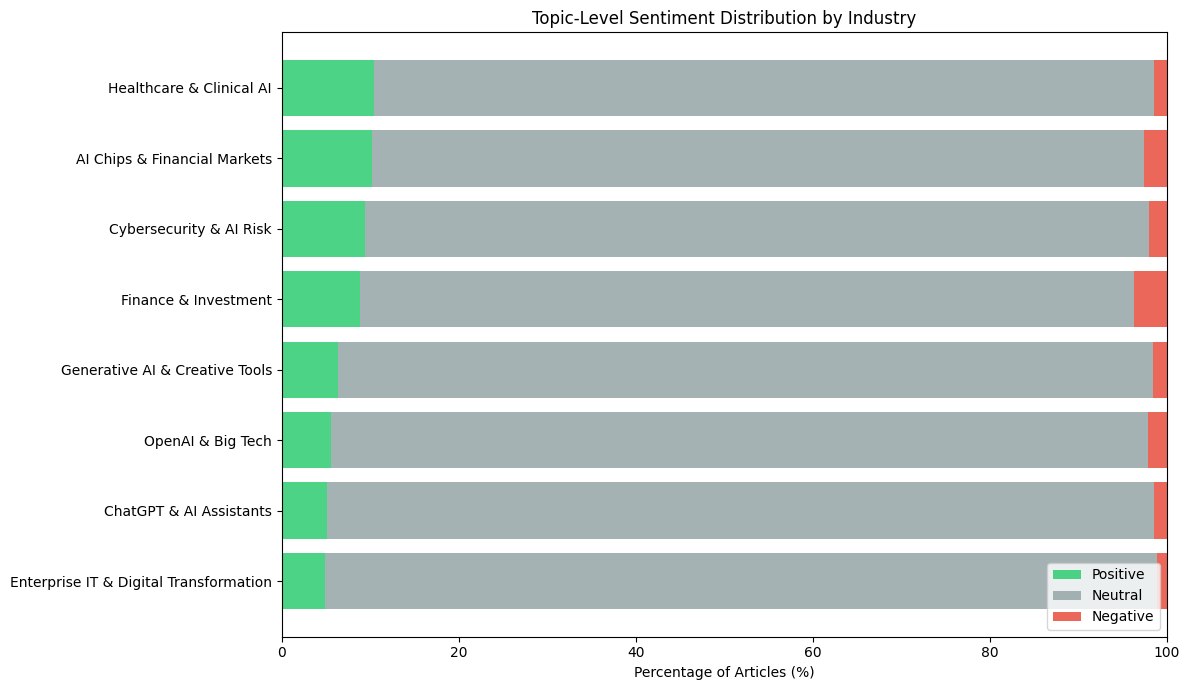

In [7]:
# ── CELL 6: Filter noise industries ───────────────────────────
NOISE_INDUSTRIES = {"Outlier / Unclustered", "Other / Mixed"}
df_use = df_merged[~df_merged["industry"].isin(NOISE_INDUSTRIES)].copy()
print(f"Articles after removing noise industries: {len(df_use)}")


# ── CELL 7: Topic-level sentiment ─────────────────────────────
topic_sentiment = (
    df_use.groupby("industry")
    .agg(
        article_count=("sentiment_compound", "count"),
        mean_compound=("sentiment_compound", "mean"),
        pct_positive=("sentiment", lambda x: (x == "positive").mean() * 100),
        pct_neutral=("sentiment",  lambda x: (x == "neutral").mean()  * 100),
        pct_negative=("sentiment", lambda x: (x == "negative").mean() * 100),
    )
    .reset_index()
    .sort_values("mean_compound", ascending=False)
)

print(topic_sentiment.to_string(index=False))

# Stacked bar chart
topic_pivot = (
    topic_sentiment
    .set_index("industry")[["pct_positive", "pct_neutral", "pct_negative"]]
    .sort_values("pct_positive", ascending=True)
)

fig, ax = plt.subplots(figsize=(12, 7))
left = np.zeros(len(topic_pivot))
for col, color, label in zip(
    ["pct_positive", "pct_neutral", "pct_negative"],
    ["#2ecc71", "#95a5a6", "#e74c3c"],
    ["Positive", "Neutral", "Negative"]
):
    ax.barh(topic_pivot.index, topic_pivot[col], left=left,
            color=color, label=label, alpha=0.85)
    left += topic_pivot[col].values
ax.set_xlabel("Percentage of Articles (%)")
ax.set_title("Topic-Level Sentiment Distribution by Industry")
ax.legend(loc="lower right")
ax.set_xlim(0, 100)
plt.tight_layout()
plt.savefig(BASE + "topic_sentiment_stacked.png", dpi=150)
plt.show()


Top 40 orgs after cleaning:
organization
Microsoft                 473
Google                    403
Nasdaq                    322
Apple                     264
OpenAI                    229
Amazon                    137
NASDAQ                    137
NYSE                      124
Samsung                   122
Intel                      97
IBM                        93
Meta                       79
AMD                        64
Nvidia                     64
RSS US                     35
GPU                        35
Size                       32
TEM                        31
GLOBE NEWSWIRE             30
Privacy Policy             30
Computer Weekly            28
Mac                        28
Huawei                     25
Independent                25
Alexa                      24
SES AI                     23
TSMC                       22
Alphabet                   22
Buy Stocks                 21
Mint                       21
GPT                        21
T-Mobile View              2

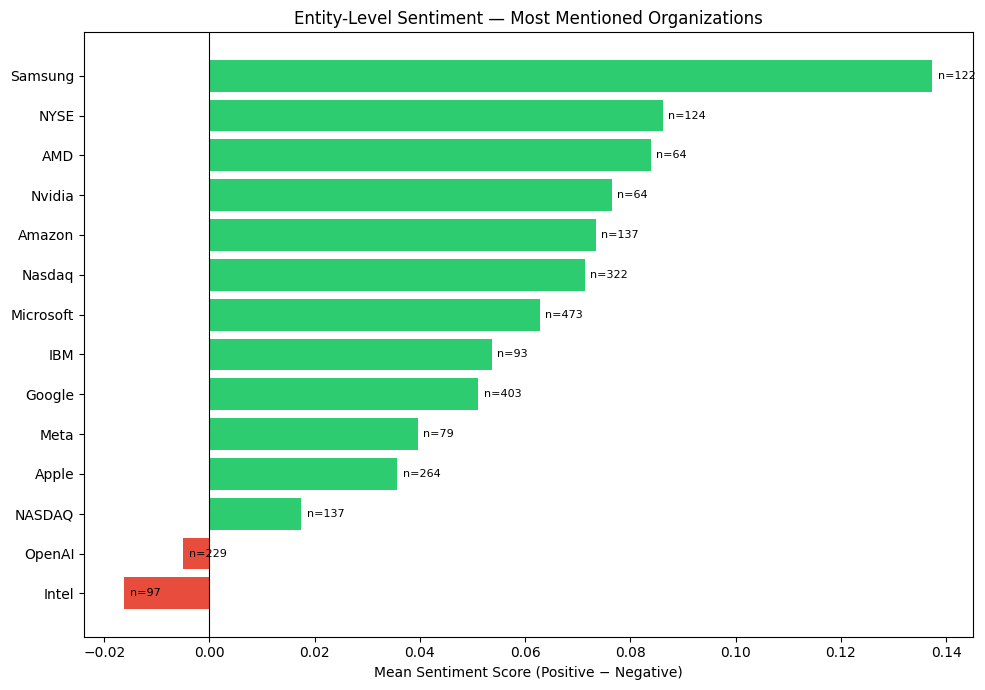

In [8]:
# ── CELL 8: Entity-level sentiment (orgs) ─────────────────────
org_long = (
    df_use[["orgs", "sentiment", "sentiment_compound", "industry"]]
    .explode("orgs")
    .rename(columns={"orgs": "organization"})
)
org_long = org_long[org_long["organization"].apply(is_valid_org)]

org_counts = org_long["organization"].value_counts()
print("\nTop 40 orgs after cleaning:")
print(org_counts.head(40).to_string())

MIN_MENTIONS = 50
top_orgs = org_counts[org_counts >= MIN_MENTIONS].index
org_long_filtered = org_long[org_long["organization"].isin(top_orgs)]
print(f"\nOrgs with {MIN_MENTIONS}+ mentions: {len(top_orgs)}")

org_summary = (
    org_long_filtered.groupby("organization")
    .agg(
        mention_count=("sentiment_compound", "count"),
        mean_sentiment=("sentiment_compound", "mean"),
        pct_positive=("sentiment", lambda x: (x == "positive").mean() * 100),
        pct_negative=("sentiment", lambda x: (x == "negative").mean() * 100),
        pct_neutral=("sentiment",  lambda x: (x == "neutral").mean()  * 100),
    )
    .reset_index()
    .sort_values("mean_sentiment", ascending=False)
)
print(org_summary.to_string(index=False))
org_summary.to_csv(BASE + "org_sentiment_summary.csv", index=False)

# Plot top 15 by mention count
plot_orgs = (
    org_summary.sort_values("mention_count", ascending=False)
    .head(15).sort_values("mean_sentiment")
)
fig, ax = plt.subplots(figsize=(10, 7))
colors = ["#e74c3c" if x < 0 else "#2ecc71" for x in plot_orgs["mean_sentiment"]]
bars = ax.barh(plot_orgs["organization"], plot_orgs["mean_sentiment"], color=colors)
ax.axvline(0, color="black", linewidth=0.8)
for bar, count in zip(bars, plot_orgs["mention_count"]):
    ax.text(bar.get_width() + 0.001, bar.get_y() + bar.get_height() / 2,
            f"n={count}", va="center", fontsize=8)
ax.set_xlabel("Mean Sentiment Score (Positive − Negative)")
ax.set_title("Entity-Level Sentiment — Most Mentioned Organizations")
plt.tight_layout()
plt.savefig(BASE + "entity_sentiment_orgs.png", dpi=150)
plt.show()


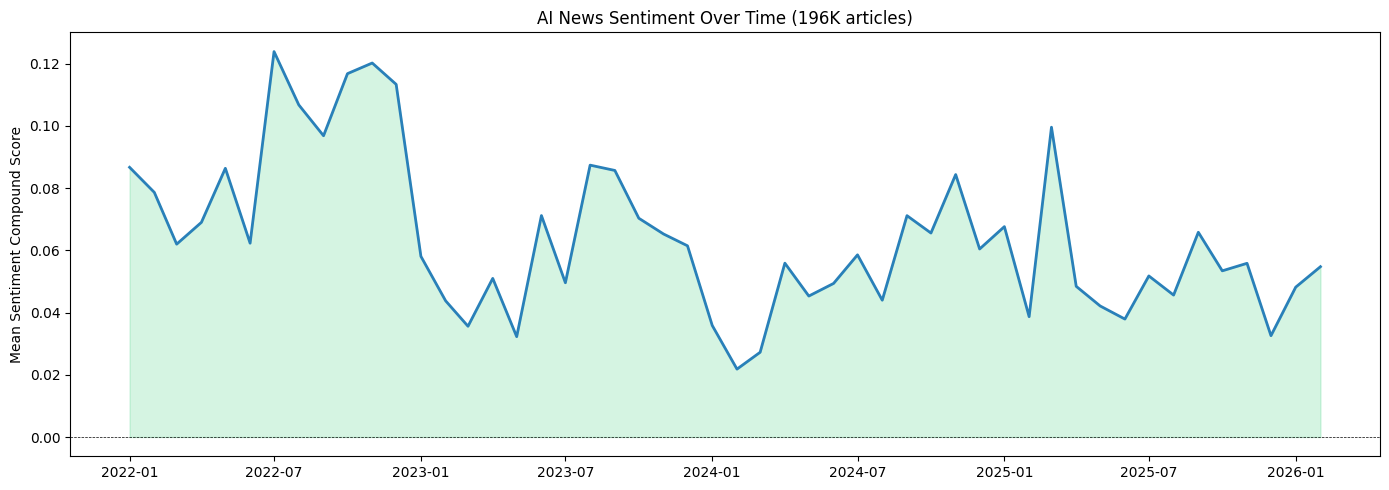

In [9]:
# ── CELL 9: Sentiment over time (full 196K) ───────────────────
df_time = df.dropna(subset=["date", "sentiment_compound"]).copy()
df_time["year_month"] = df_time["date"].dt.to_period("M")

time_ts = (
    df_time.groupby("year_month")["sentiment_compound"]
    .mean().reset_index()
)
time_ts["year_month_dt"] = time_ts["year_month"].dt.to_timestamp()

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(time_ts["year_month_dt"], time_ts["sentiment_compound"],
        color="#2980b9", linewidth=2)
ax.axhline(0, color="black", linewidth=0.5, linestyle="--")
ax.fill_between(time_ts["year_month_dt"], time_ts["sentiment_compound"], 0,
                where=time_ts["sentiment_compound"] > 0, alpha=0.2, color="#2ecc71")
ax.fill_between(time_ts["year_month_dt"], time_ts["sentiment_compound"], 0,
                where=time_ts["sentiment_compound"] < 0, alpha=0.2, color="#e74c3c")
ax.set_ylabel("Mean Sentiment Compound Score")
ax.set_title("AI News Sentiment Over Time (196K articles)")
plt.tight_layout()
plt.savefig(BASE + "sentiment_over_time.png", dpi=150)
plt.show()


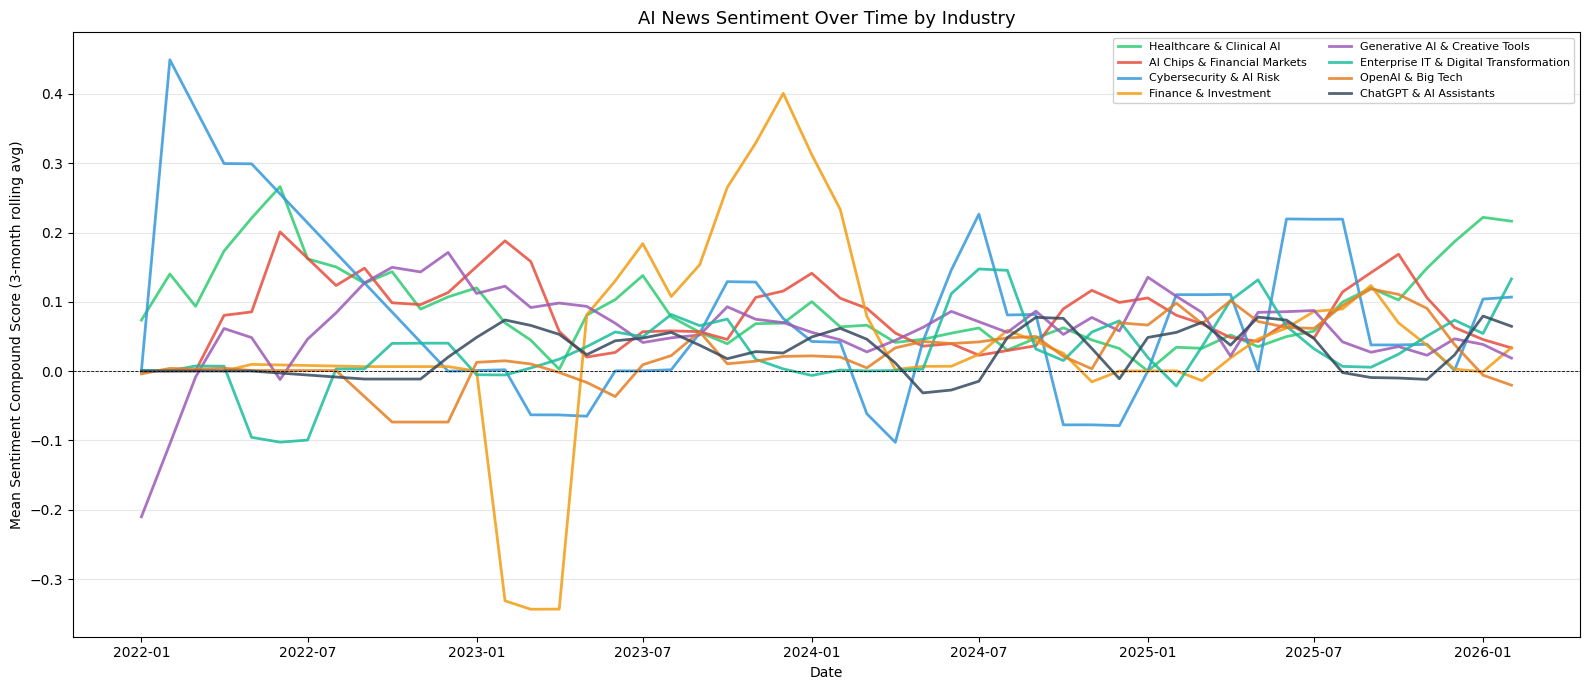

In [10]:
# ── CELL 11: All industries sentiment over time ────────────────
url_to_industry = df_merged[["url", "industry"]].drop_duplicates(subset="url")
df_with_industry = df.merge(url_to_industry, on="url", how="left")
df_with_industry["date"] = pd.to_datetime(df_with_industry["date"], errors="coerce")

all_industries = topic_sentiment[
    ~topic_sentiment["industry"].isin(NOISE_INDUSTRIES)
]["industry"].tolist()

colors_15 = [
    "#2ecc71", "#e74c3c", "#3498db", "#f39c12", "#9b59b6",
    "#1abc9c", "#e67e22", "#34495e", "#e91e63", "#00bcd4",
    "#8bc34a", "#ff5722", "#607d8b", "#795548", "#ffc107"
]

fig, ax = plt.subplots(figsize=(16, 7))
for i, industry in enumerate(all_industries):
    df_ind = df_with_industry[df_with_industry["industry"] == industry].copy()
    df_ind["year_month"] = df_ind["date"].dt.to_period("M")
    ts = df_ind.groupby("year_month")["sentiment_compound"].mean().reset_index()
    ts["year_month_dt"] = ts["year_month"].dt.to_timestamp()
    ts["smoothed"] = ts["sentiment_compound"].rolling(window=3, min_periods=1).mean()
    ax.plot(ts["year_month_dt"], ts["smoothed"], linewidth=2,
            label=industry, color=colors_15[i % len(colors_15)], alpha=0.85)

ax.axhline(0, color="black", linewidth=0.6, linestyle="--")
ax.set_ylabel("Mean Sentiment Compound Score (3-month rolling avg)", fontsize=10)
ax.set_xlabel("Date", fontsize=10)
ax.set_title("AI News Sentiment Over Time by Industry", fontsize=13)
ax.legend(loc="upper right", fontsize=8, framealpha=0.9, ncol=2)
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig(BASE + "sentiment_over_time_by_industry.png", dpi=150)
plt.show()

Tech terms: 6299
technology
gpt                     2354
rag                      924
chatbot                  543
agent                    463
gpu                      306
agents                   201
lora                     187
gemini                   187
bert                     163
llm                      144
copilot                  135
claude                   125
deepfake                 123
agentic                  111
large language model      79
malware                   35
dall-e                    32
diffusion                 26
stable diffusion          21
tpu                       20
          technology  mention_count  mean_sentiment  pct_positive  pct_negative
                 gpt           2354        0.022435      4.672897      2.293968
                 rag            924        0.076818     10.173160      3.354978
             chatbot            543        0.024629      4.972376      2.025783
               agent            463        0.131925     14.038877      0

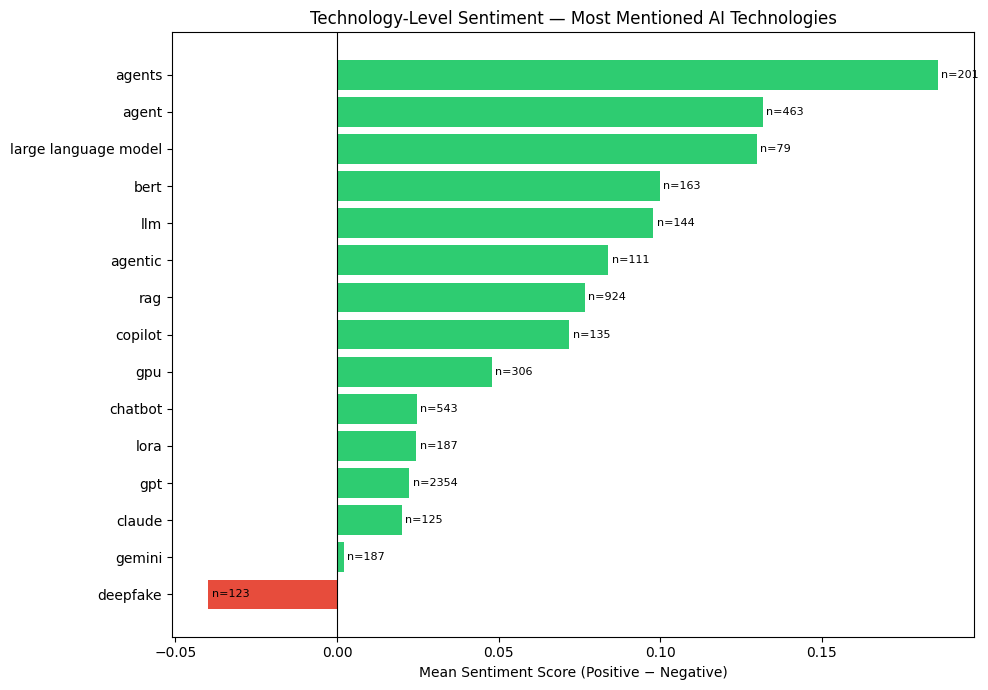

In [11]:
# ── CELL 13: Tech sentiment ────────────────────────────────────
def clean_tech(val):
    return re.sub(r"[\[\]']", "", str(val)).strip().lower()

tech_long = (
    df_merged[["url", "tech_parsed", "sentiment", "sentiment_compound", "industry"]]
    .explode("tech_parsed")
    .rename(columns={"tech_parsed": "technology"})
)
tech_long["technology"] = tech_long["technology"].apply(clean_tech)
tech_long = tech_long[
    tech_long["technology"].notna() &
    (tech_long["technology"] != "") &
    (tech_long["technology"] != "nan") &
    (tech_long["technology"].str.len() > 1)
]

print(f"Tech terms: {len(tech_long)}")
print(tech_long["technology"].value_counts().head(20).to_string())

tech_counts = tech_long["technology"].value_counts()
top_tech = tech_counts[tech_counts >= 5].index

tech_summary = (
    tech_long[tech_long["technology"].isin(top_tech)]
    .groupby("technology")
    .agg(
        mention_count=("sentiment_compound", "count"),
        mean_sentiment=("sentiment_compound", "mean"),
        pct_positive=("sentiment", lambda x: (x == "positive").mean() * 100),
        pct_negative=("sentiment", lambda x: (x == "negative").mean() * 100),
    )
    .reset_index()
    .sort_values("mention_count", ascending=False)
)

print(tech_summary.head(20).to_string(index=False))
tech_summary.to_csv(BASE + "tech_sentiment_summary.csv", index=False)

# Plot top 15
plot_tech = tech_summary.head(15).sort_values("mean_sentiment")
fig, ax = plt.subplots(figsize=(10, 7))
colors = ["#e74c3c" if x < 0 else "#2ecc71" for x in plot_tech["mean_sentiment"]]
bars = ax.barh(plot_tech["technology"], plot_tech["mean_sentiment"], color=colors)
ax.axvline(0, color="black", linewidth=0.8)
for bar, count in zip(bars, plot_tech["mention_count"]):
    ax.text(bar.get_width() + 0.001, bar.get_y() + bar.get_height() / 2,
            f"n={count}", va="center", fontsize=8)
ax.set_xlabel("Mean Sentiment Score (Positive − Negative)")
ax.set_title("Technology-Level Sentiment — Most Mentioned AI Technologies")
plt.tight_layout()
plt.savefig(BASE + "tech_sentiment_bar.png", dpi=150)
plt.show()


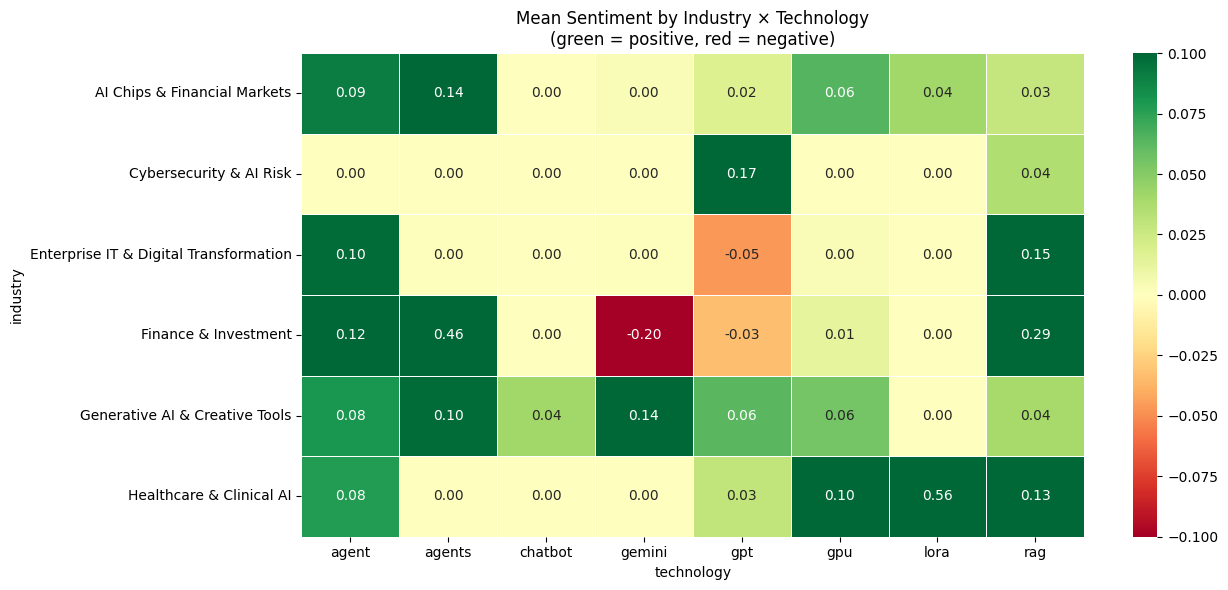

In [12]:
# Tech × Industry heatmap
top_8_tech = tech_summary.head(8)["technology"].tolist()
top_6_industries = topic_sentiment.head(6)["industry"].tolist()

tech_industry = (
    tech_long[
        tech_long["technology"].isin(top_8_tech) &
        tech_long["industry"].isin(top_6_industries)
    ]
    .groupby(["industry", "technology"])["sentiment_compound"]
    .mean().reset_index()
    .pivot(index="industry", columns="technology", values="sentiment_compound")
    .fillna(0)
)

fig, ax = plt.subplots(figsize=(13, 6))
sns.heatmap(tech_industry, cmap="RdYlGn", center=0, annot=True, fmt=".2f",
            linewidths=0.5, ax=ax, vmin=-0.1, vmax=0.1)
ax.set_title("Mean Sentiment by Industry × Technology\n(green = positive, red = negative)")
plt.tight_layout()
plt.savefig(BASE + "tech_industry_heatmap.png", dpi=150)
plt.show()

── Industry Summary ──
                              industry  article_count  ai_exposure  mean_compound  sentiment_trajectory  controversy_score
        Generative AI & Creative Tools           2505         34.5       0.048686             -0.000296               19.4
          AI Chips & Financial Markets           1425         19.6       0.075854             -0.000529               20.2
              Healthcare & Clinical AI            885         12.2       0.089964             -0.000610               12.4
                     OpenAI & Big Tech            793         10.9       0.036688              0.001937               27.9
               ChatGPT & AI Assistants            622          8.6       0.033860              0.000355               22.0
Enterprise IT & Digital Transformation            450          6.2       0.041695              0.002200               18.5
                  Finance & Investment            430          5.9       0.054713              0.001127             

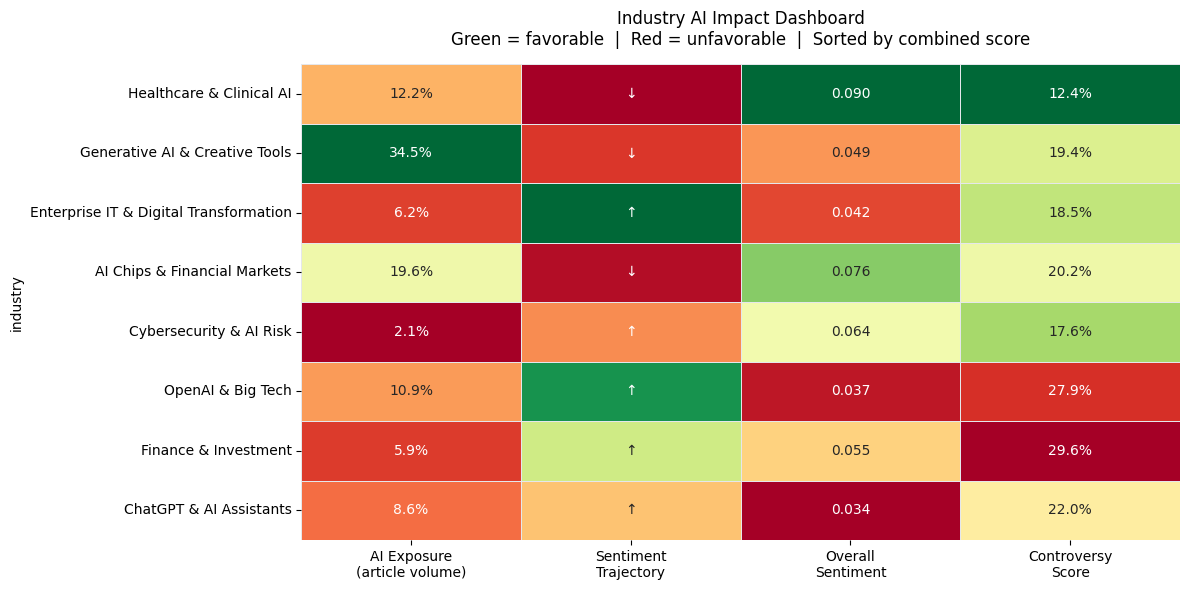

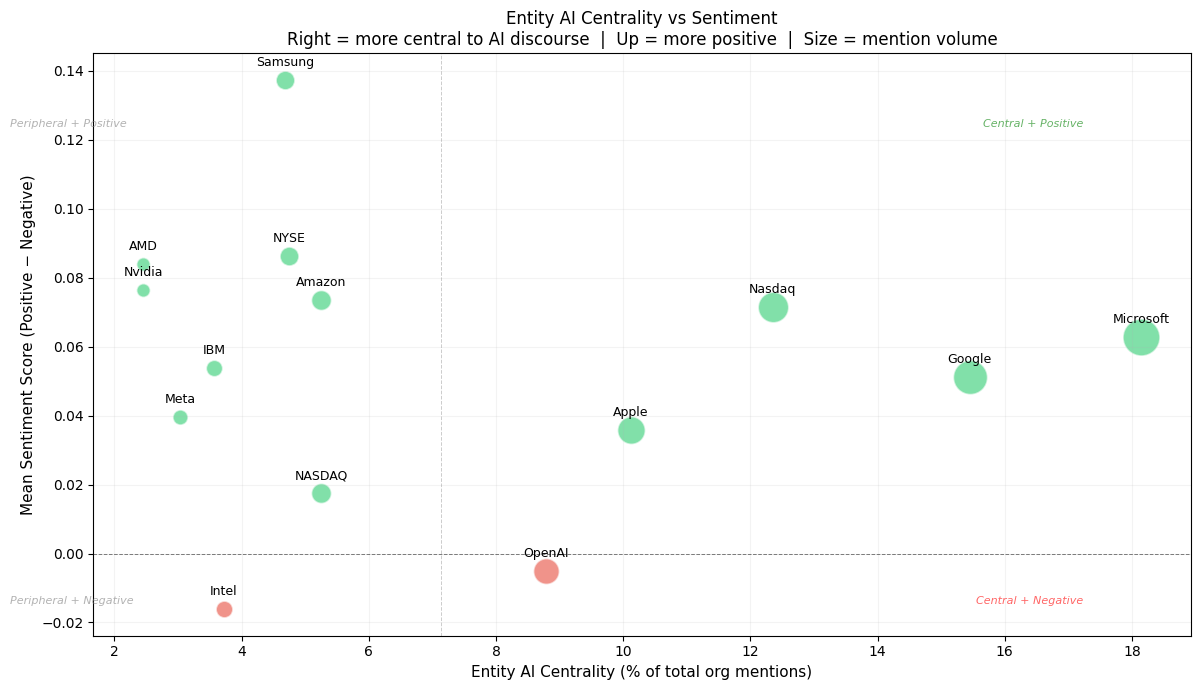


── FINAL INDUSTRY VERDICT TABLE ──
                              industry  ai_exposure  Exposure  Trajectory        Controversy
        Generative AI & Creative Tools         34.5 Very High ↓ Declining Somewhat Contested
          AI Chips & Financial Markets         19.6      High ↓ Declining Somewhat Contested
              Healthcare & Clinical AI         12.2    Medium ↓ Declining   Largely Positive
                     OpenAI & Big Tech         10.9    Medium ↑ Improving   Highly Contested
               ChatGPT & AI Assistants          8.6    Medium ↑ Improving Somewhat Contested
Enterprise IT & Digital Transformation          6.2       Low ↑ Improving Somewhat Contested
                  Finance & Investment          5.9       Low ↑ Improving   Highly Contested
               Cybersecurity & AI Risk          2.1       Low    → Stable Somewhat Contested


In [13]:
# ── CELL 16: Derived Variables ────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

NOISE_INDUSTRIES = {"Outlier / Unclustered", "Other / Mixed"}

# ── 1. AI Exposure Index ───────────────────────────────────────
total_articles = topic_sentiment["article_count"].sum()
topic_sentiment["ai_exposure"] = (
    topic_sentiment["article_count"] / total_articles * 100
).round(1)

# ── 2. Sentiment Trajectory ────────────────────────────────────
trajectory = {}
for industry in topic_sentiment["industry"]:
    if industry in NOISE_INDUSTRIES:
        continue
    df_ind = df_with_industry[df_with_industry["industry"] == industry].copy()
    df_ind["year_month"] = df_ind["date"].dt.to_period("M")
    ts = df_ind.groupby("year_month")["sentiment_compound"].mean().reset_index()
    ts["t"] = np.arange(len(ts))
    if len(ts) < 6:
        trajectory[industry] = 0.0
        continue
    slope = np.polyfit(ts["t"], ts["sentiment_compound"], 1)[0]
    trajectory[industry] = round(slope, 6)

topic_sentiment["sentiment_trajectory"] = topic_sentiment["industry"].map(trajectory)

# ── 3. Controversy Score ───────────────────────────────────────
topic_sentiment["controversy_score"] = (
    topic_sentiment["pct_negative"] /
    (topic_sentiment["pct_positive"] + topic_sentiment["pct_negative"] + 1e-9)
    * 100
).round(1)

# ── 4. Entity AI Centrality ────────────────────────────────────
total_org_mentions = org_summary["mention_count"].sum()
org_summary["ai_centrality"] = (
    org_summary["mention_count"] / total_org_mentions * 100
).round(2)

# ── Build industry_summary ─────────────────────────────────────
# Single source of truth — all 4 derived columns in one place
industry_summary = topic_sentiment[[
    "industry", "article_count", "ai_exposure",
    "mean_compound", "sentiment_trajectory", "controversy_score"
]].sort_values("ai_exposure", ascending=False).copy()

print("── Industry Summary ──")
print(industry_summary.to_string(index=False))

print("\n── Org Centrality ──")
org_centrality = org_summary[[
    "organization", "mention_count", "ai_centrality",
    "mean_sentiment", "pct_positive", "pct_negative"
]].sort_values("ai_centrality", ascending=False).head(15)
print(org_centrality.to_string(index=False))


# ── Industry Impact Dashboard Heatmap ─────────────────────────
df_heat = industry_summary[
    ~industry_summary["industry"].isin(NOISE_INDUSTRIES)
].copy().set_index("industry")

def norm_col(col, reverse=False):
    mn, mx = col.min(), col.max()
    n = (col - mn) / (mx - mn + 1e-9)
    return 1 - n if reverse else n

df_plot = pd.DataFrame({
    "AI Exposure\n(article volume)"  : norm_col(df_heat["ai_exposure"]),
    "Sentiment\nTrajectory"          : norm_col(df_heat["sentiment_trajectory"]),
    "Overall\nSentiment"             : norm_col(df_heat["mean_compound"]),
    "Controversy\nScore"             : norm_col(df_heat["controversy_score"], reverse=True),
}, index=df_heat.index)

df_plot["_score"] = df_plot.mean(axis=1)
df_plot = df_plot.sort_values("_score", ascending=False).drop(columns="_score")

annot_data = pd.DataFrame({
    "AI Exposure\n(article volume)"  : df_heat.loc[df_plot.index, "ai_exposure"].map(lambda x: f"{x:.1f}%"),
    "Sentiment\nTrajectory"          : df_heat.loc[df_plot.index, "sentiment_trajectory"].map(lambda x: "↑" if x > 0 else "↓"),
    "Overall\nSentiment"             : df_heat.loc[df_plot.index, "mean_compound"].map(lambda x: f"{x:.3f}"),
    "Controversy\nScore"             : df_heat.loc[df_plot.index, "controversy_score"].map(lambda x: f"{x:.1f}%"),
}, index=df_plot.index)

fig, ax = plt.subplots(figsize=(12, 6))
sns.heatmap(
    df_plot, cmap="RdYlGn", ax=ax,
    annot=annot_data, fmt="",
    linewidths=0.5, linecolor="#e5e7eb",
    cbar=False, vmin=0, vmax=1
)
ax.set_title(
    "Industry AI Impact Dashboard\n"
    "Green = favorable  |  Red = unfavorable  |  Sorted by combined score",
    fontsize=12, pad=14
)
ax.tick_params(axis="y", rotation=0, labelsize=10)
ax.tick_params(axis="x", labelsize=10)
plt.tight_layout()
plt.savefig(BASE + "industry_impact_dashboard.png", dpi=150)
plt.show()


# ── Entity Centrality vs Sentiment Scatter ────────────────────
fig, ax = plt.subplots(figsize=(12, 7))

for _, row in org_centrality.iterrows():
    color = "#2ecc71" if row["mean_sentiment"] >= 0 else "#e74c3c"
    ax.scatter(
        row["ai_centrality"], row["mean_sentiment"],
        s=row["mention_count"] * 1.5,
        color=color, alpha=0.6,
        edgecolors="white", linewidths=1.2
    )
    ax.annotate(
        row["organization"],
        (row["ai_centrality"], row["mean_sentiment"]),
        fontsize=9, ha="center", va="bottom",
        xytext=(0, 8), textcoords="offset points",
        fontweight="500"
    )

ax.axhline(0, color="black", linewidth=0.7, linestyle="--", alpha=0.5)
ax.axvline(
    org_centrality["ai_centrality"].mean(),
    color="gray", linewidth=0.7, linestyle="--", alpha=0.4
)

xmax = org_centrality["ai_centrality"].max()
ymax = org_centrality["mean_sentiment"].max()
ymin = org_centrality["mean_sentiment"].min()

ax.text(xmax * 0.95, ymax * 0.9, "Central + Positive",
        fontsize=8, color="green", alpha=0.6, ha="right", style="italic")
ax.text(xmax * 0.95, ymin * 0.9, "Central + Negative",
        fontsize=8, color="red", alpha=0.6, ha="right", style="italic")
ax.text(org_centrality["ai_centrality"].mean() * 0.05, ymax * 0.9,
        "Peripheral + Positive", fontsize=8, color="gray",
        alpha=0.6, ha="left", style="italic")
ax.text(org_centrality["ai_centrality"].mean() * 0.05, ymin * 0.9,
        "Peripheral + Negative", fontsize=8, color="gray",
        alpha=0.6, ha="left", style="italic")

ax.set_xlabel("Entity AI Centrality (% of total org mentions)", fontsize=11)
ax.set_ylabel("Mean Sentiment Score (Positive − Negative)", fontsize=11)
ax.set_title(
    "Entity AI Centrality vs Sentiment\n"
    "Right = more central to AI discourse  |  Up = more positive  |  Size = mention volume",
    fontsize=12
)
ax.grid(alpha=0.15)
plt.tight_layout()
plt.savefig(BASE + "entity_centrality_sentiment.png", dpi=150)
plt.show()


# ── Final Verdict Table ────────────────────────────────────────
print("\n── FINAL INDUSTRY VERDICT TABLE ──")

def trajectory_label(v):
    if pd.isna(v):    return "→ Stable"
    if v > 0.0001:    return "↑ Improving"
    if v < -0.0001:   return "↓ Declining"
    return "→ Stable"

def exposure_label(v):
    if pd.isna(v):  return "Unknown"
    if v > 25:      return "Very High"
    if v > 15:      return "High"
    if v > 8:       return "Medium"
    return "Low"

def controversy_label(v):
    if pd.isna(v):  return "Unknown"
    if v > 25:      return "Highly Contested"
    if v > 15:      return "Somewhat Contested"
    return "Largely Positive"

verdict_df = industry_summary[
    ~industry_summary["industry"].isin(NOISE_INDUSTRIES)
].copy()

verdict_df["Exposure"]    = verdict_df["ai_exposure"].apply(exposure_label)
verdict_df["Trajectory"]  = verdict_df["sentiment_trajectory"].apply(trajectory_label)
verdict_df["Controversy"] = verdict_df["controversy_score"].apply(controversy_label)

print(verdict_df[[
    "industry", "ai_exposure", "Exposure", "Trajectory", "Controversy"
]].sort_values("ai_exposure", ascending=False).to_string(index=False))

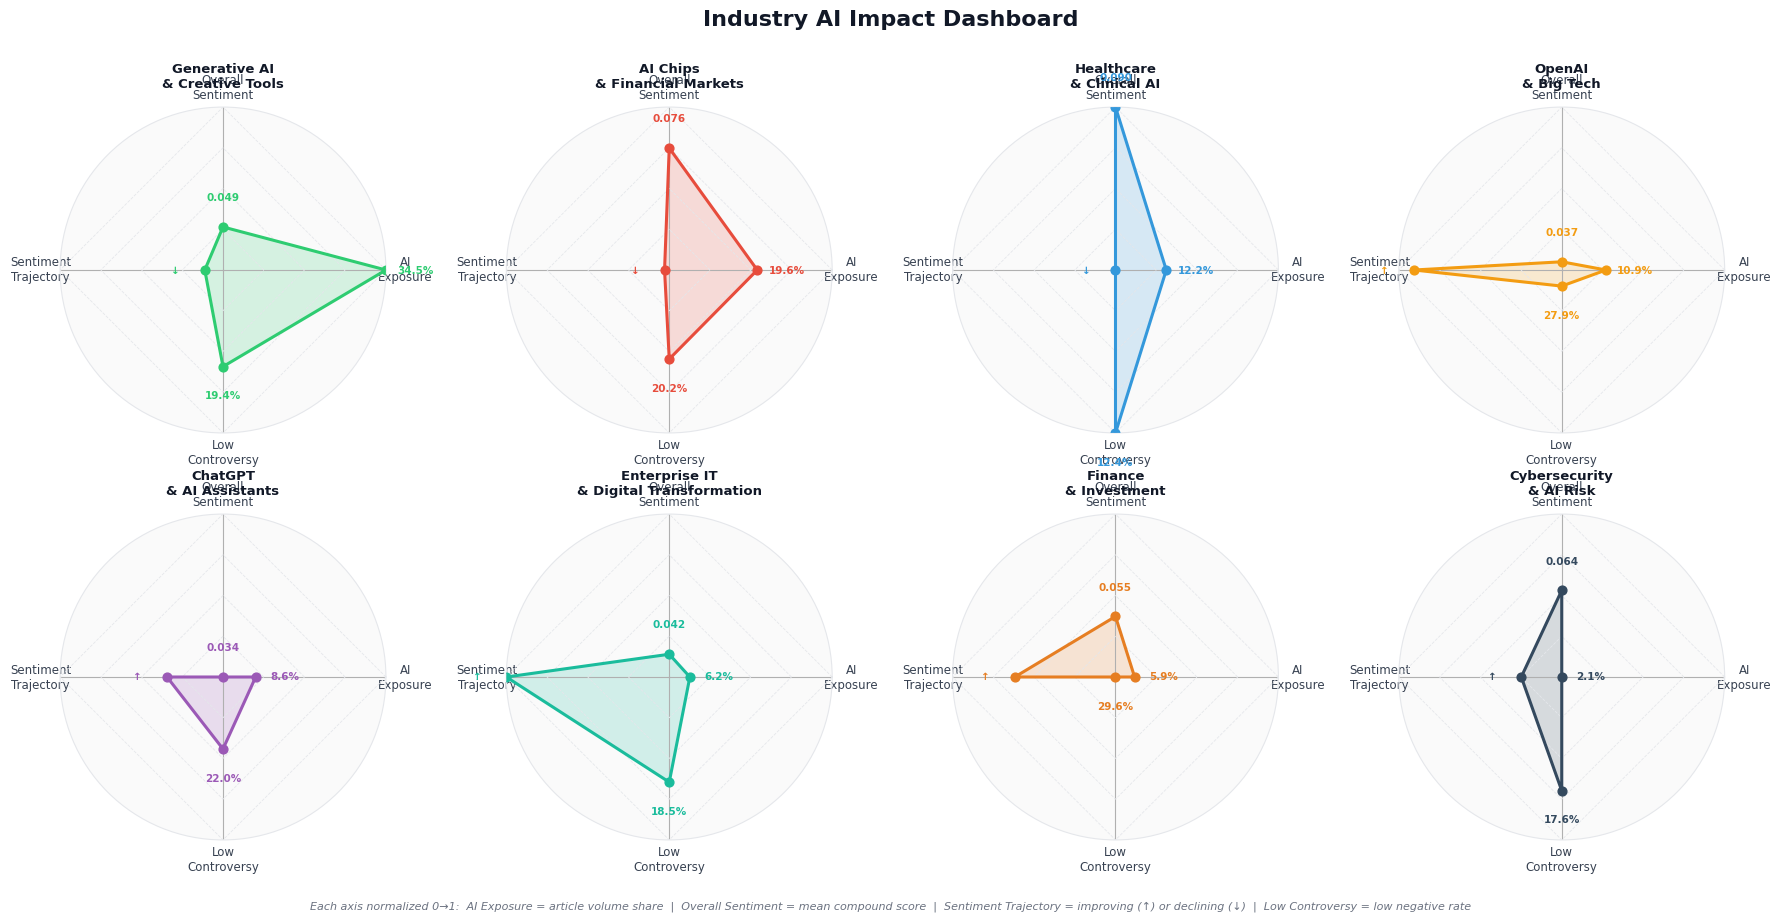

In [14]:
# ── CELL 16b: Radar / Spider Chart — Industry AI Impact Dashboard ──
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import FancyArrowPatch

NOISE_INDUSTRIES = {"Outlier / Unclustered", "Other / Mixed"}

df_radar = industry_summary[
    ~industry_summary["industry"].isin(NOISE_INDUSTRIES)
].copy()

# Normalize each metric 0-1 for radar
def norm_col(series, reverse=False):
    mn, mx = series.min(), series.max()
    n = (series - mn) / (mx - mn + 1e-9)
    return (1 - n) if reverse else n

df_radar["exp_norm"]   = norm_col(df_radar["ai_exposure"])
df_radar["sent_norm"]  = norm_col(df_radar["mean_compound"])
df_radar["traj_norm"]  = norm_col(df_radar["sentiment_trajectory"])
df_radar["cont_norm"]  = norm_col(df_radar["controversy_score"], reverse=True)

CATEGORIES   = ["AI\nExposure", "Overall\nSentiment", "Sentiment\nTrajectory", "Low\nControversy"]
METRICS      = ["exp_norm", "sent_norm", "traj_norm", "cont_norm"]
N            = len(CATEGORIES)
angles       = [n / float(N) * 2 * np.pi for n in range(N)]
angles      += angles[:1]  # close the loop

industries   = df_radar["industry"].tolist()
n_industries = len(industries)

# Grid layout — 2 rows x 4 cols
COLS, ROWS = 4, 2
fig, axes = plt.subplots(
    ROWS, COLS,
    figsize=(18, 9),
    subplot_kw=dict(polar=True)
)
axes = axes.flatten()

COLORS = [
    "#2ecc71", "#e74c3c", "#3498db", "#f39c12",
    "#9b59b6", "#1abc9c", "#e67e22", "#34495e"
]

for i, (_, row) in enumerate(df_radar.iterrows()):
    ax = axes[i]
    values = [row[m] for m in METRICS]
    values += values[:1]  # close loop

    color = COLORS[i % len(COLORS)]

    # Background grid rings
    for r in [0.25, 0.5, 0.75, 1.0]:
        ax.plot(angles, [r] * (N + 1), color="#e5e7eb", linewidth=0.6, linestyle="--")

    # Filled area
    ax.fill(angles, values, alpha=0.18, color=color)
    ax.plot(angles, values, color=color, linewidth=2.2, linestyle="solid")

    # Data point dots
    ax.scatter(angles[:-1], values[:-1], color=color, s=40, zorder=5)

    # Category labels
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(CATEGORIES, size=8.5, color="#374151", fontweight="500")

    # Remove radial labels and set limits
    ax.set_yticks([])
    ax.set_ylim(0, 1)

    # Add actual value annotations near each point
    actual_vals = [
        f"{row['ai_exposure']:.1f}%",
        f"{row['mean_compound']:.3f}",
        "↑" if row["sentiment_trajectory"] > 0 else "↓",
        f"{row['controversy_score']:.1f}%",
    ]
    for angle, val_norm, actual in zip(angles[:-1], values[:-1], actual_vals):
        ax.annotate(
            actual,
            xy=(angle, val_norm),
            xytext=(angle, val_norm + 0.18),
            ha="center", va="center",
            fontsize=7.5, color=color, fontweight="600"
        )

    # Remove outer spine
    ax.spines["polar"].set_color("#e5e7eb")
    ax.spines["polar"].set_linewidth(0.8)
    ax.set_facecolor("#fafafa")

    # Industry title inside chart
    short_name = row["industry"].replace(" & ", "\n& ")
    ax.set_title(short_name, size=9.5, fontweight="700",
                 color="#111827", pad=14, loc="center")

# Hide unused axes if < 8 industries
for j in range(n_industries, ROWS * COLS):
    axes[j].set_visible(False)

# Legend for what each axis means
legend_text = (
    "Each axis normalized 0→1:  "
    "AI Exposure = article volume share  |  "
    "Overall Sentiment = mean compound score  |  "
    "Sentiment Trajectory = improving (↑) or declining (↓)  |  "
    "Low Controversy = low negative rate"
)
fig.text(0.5, 0.01, legend_text, ha="center", fontsize=8,
         color="#6b7280", style="italic")

fig.suptitle(
    "Industry AI Impact Dashboard",
    fontsize=16, fontweight="700", color="#111827", y=1.01
)

plt.tight_layout(rect=[0, 0.04, 1, 1])
plt.savefig(BASE + "industry_impact_radar.png", dpi=150, bbox_inches="tight")
plt.show()

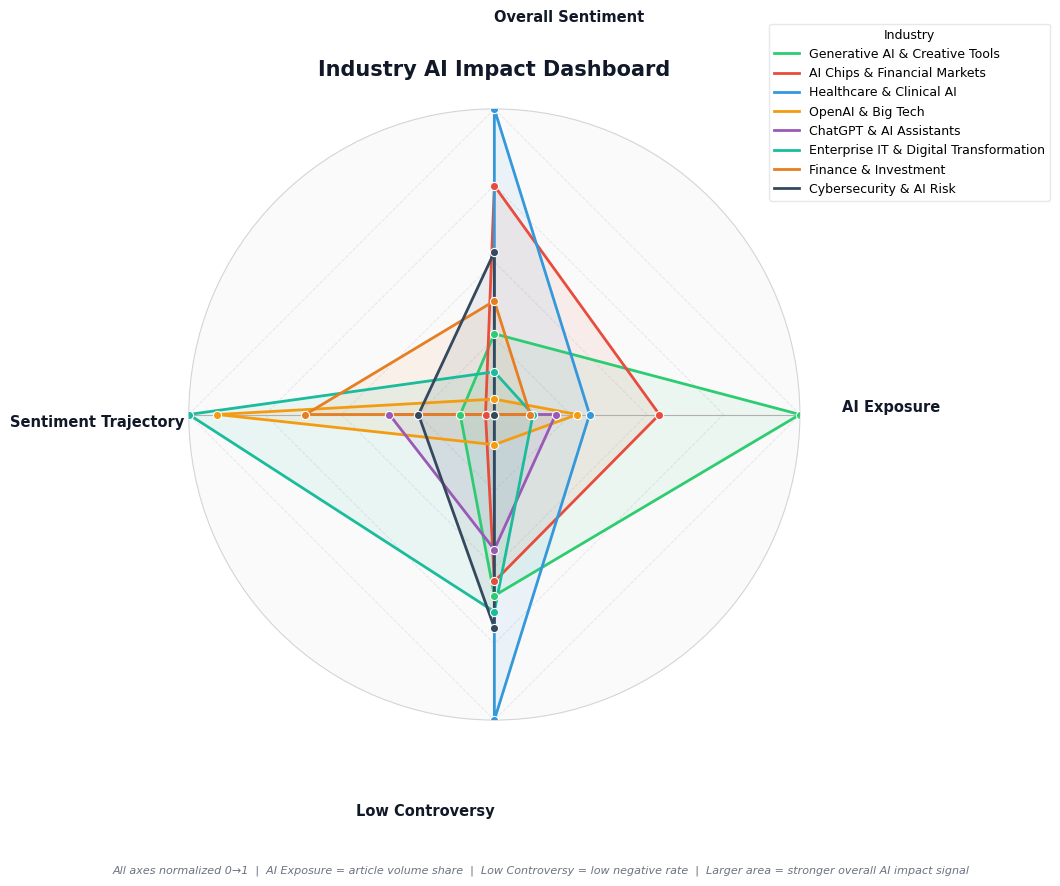

In [15]:
# ── CELL 16c: Overlapping Radar Chart — axis labels outside ───
import numpy as np
import matplotlib.pyplot as plt

NOISE_INDUSTRIES = {"Outlier / Unclustered", "Other / Mixed"}

df_radar = industry_summary[
    ~industry_summary["industry"].isin(NOISE_INDUSTRIES)
].copy()

def norm_col(series, reverse=False):
    mn, mx = series.min(), series.max()
    n = (series - mn) / (mx - mn + 1e-9)
    return (1 - n) if reverse else n

df_radar["exp_norm"]  = norm_col(df_radar["ai_exposure"])
df_radar["sent_norm"] = norm_col(df_radar["mean_compound"])
df_radar["traj_norm"] = norm_col(df_radar["sentiment_trajectory"])
df_radar["cont_norm"] = norm_col(df_radar["controversy_score"], reverse=True)

CATEGORIES = ["AI Exposure", "Overall Sentiment", "Sentiment Trajectory", "Low Controversy"]
METRICS    = ["exp_norm", "sent_norm", "traj_norm", "cont_norm"]
N          = len(CATEGORIES)
angles     = [n / float(N) * 2 * np.pi for n in range(N)]
angles    += angles[:1]

COLORS = [
    "#2ecc71", "#e74c3c", "#3498db", "#f39c12",
    "#9b59b6", "#1abc9c", "#e67e22", "#34495e"
]

fig, ax = plt.subplots(figsize=(11, 9), subplot_kw=dict(polar=True))

# ── Background grid rings ──────────────────────────────────────
for r in [0.25, 0.5, 0.75, 1.0]:
    ax.plot(angles, [r] * (N + 1), color="#e5e7eb",
            linewidth=0.7, linestyle="--", zorder=0)

# ── Spoke lines ────────────────────────────────────────────────
for angle in angles[:-1]:
    ax.plot([angle, angle], [0, 1], color="#e5e7eb", linewidth=0.7, zorder=0)

# ── Plot each industry ─────────────────────────────────────────
for i, (_, row) in enumerate(df_radar.iterrows()):
    values = [row[m] for m in METRICS] + [row[METRICS[0]]]
    color  = COLORS[i % len(COLORS)]
    ax.fill(angles, values, alpha=0.08, color=color)
    ax.plot(angles, values, color=color, linewidth=2,
            linestyle="solid", label=row["industry"], zorder=3)
    ax.scatter(angles[:-1], values[:-1], color=color,
               s=35, zorder=5, edgecolors="white", linewidths=0.8)

# ── Remove default xtick labels completely ─────────────────────
ax.set_xticks(angles[:-1])
ax.set_xticklabels([""] * N)  # blank — we draw manually below
ax.set_yticks([])
ax.set_ylim(0, 1)
ax.spines["polar"].set_color("#d1d5db")
ax.spines["polar"].set_linewidth(0.8)
ax.set_facecolor("#fafafa")

# ── Manually place axis labels further outside ─────────────────
# Push labels to r=1.28 so they clear the radar boundary cleanly
LABEL_R = 1.3  # just outside the outer ring

for i, (label, angle) in enumerate(zip(CATEGORIES, angles[:-1])):
    # ha/va based on which quadrant the label falls in
    if np.isclose(np.sin(angle), 0, atol=0.1):   # top or bottom spoke
        ha = "center"
    elif np.sin(angle) > 0:
        ha = "left"
    else:
        ha = "right"

    if np.isclose(np.cos(angle), 0, atol=0.1):   # left or right spoke
        va = "center"
    elif np.cos(angle) > 0:
        va = "bottom"
    else:
        va = "top"

    ax.text(
        angle, LABEL_R, label,
        ha=ha, va=va,
        fontsize=10.5, fontweight="600", color="#111827",
        transform=ax.transData
    )

# ── Legend ─────────────────────────────────────────────────────
ax.legend(
    loc="upper right",
    bbox_to_anchor=(1.42, 1.15),
    fontsize=9,
    framealpha=0.95,
    edgecolor="#e5e7eb",
    title="Industry",
    title_fontsize=9,
)

fig.text(
    0.5, 0.01,
    "All axes normalized 0→1  |  "
    "AI Exposure = article volume share  |  "
    "Low Controversy = low negative rate  |  "
    "Larger area = stronger overall AI impact signal",
    ha="center", fontsize=8, color="#6b7280", style="italic"
)

ax.set_title(
    "Industry AI Impact Dashboard",
    fontsize=15, fontweight="700", color="#111827", pad=24
)

plt.tight_layout(rect=[0, 0.04, 1, 1])
plt.savefig(BASE + "industry_impact_radar_overlap.png", dpi=150, bbox_inches="tight")
plt.show()

In [16]:
!pip install squarify -q

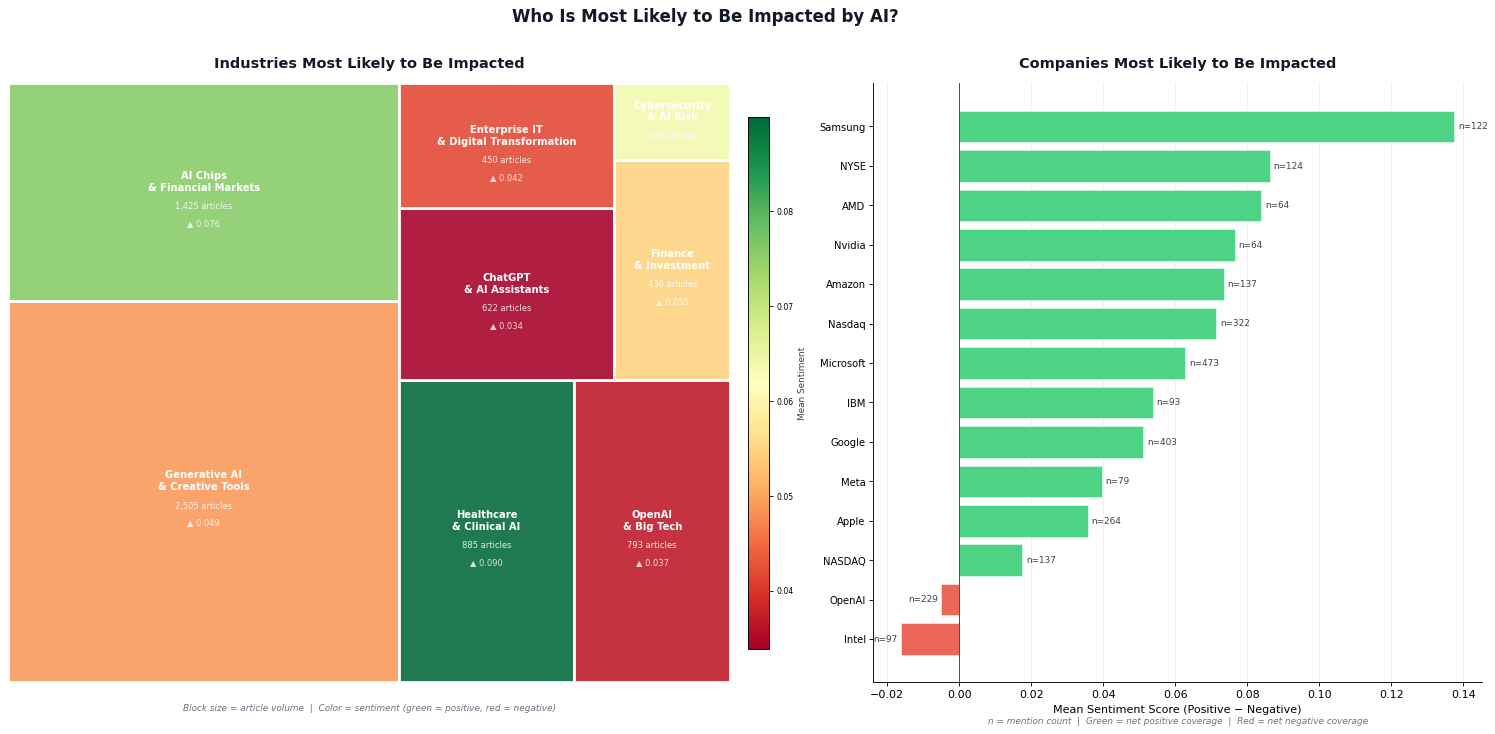

In [17]:
# ── CELL 17: Two-chart figure — Treemap + Company Bar ─────────
# !pip install squarify -q

import squarify
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.colors as mcolors
import matplotlib
import numpy as np

matplotlib.rcParams['figure.dpi'] = 80
plt.rcParams['path.simplify'] = True
plt.rcParams['path.simplify_threshold'] = 1.0

NOISE_INDUSTRIES = {"Outlier / Unclustered", "Other / Mixed"}

# ── Data ───────────────────────────────────────────────────────
df_tree_ind = industry_summary[
    ~industry_summary["industry"].isin(NOISE_INDUSTRIES)
].copy().sort_values("article_count", ascending=False)

# Top 15 orgs by mention count with sentiment
plot_orgs = (
    org_summary
    .sort_values("mention_count", ascending=False)
    .head(15)
    .sort_values("mean_sentiment")
    .copy()
)

# ── Colormap ───────────────────────────────────────────────────
cmap     = plt.cm.RdYlGn
sent_min = df_tree_ind["mean_compound"].min()
sent_max = df_tree_ind["mean_compound"].max()

def sentiment_to_color(val, alpha=0.88):
    norm = (val - sent_min) / (sent_max - sent_min + 1e-9)
    rgba = list(cmap(norm))
    rgba[3] = alpha
    return rgba

# ── Figure: 2 panels side by side ─────────────────────────────
fig, (ax_tree, ax_bar) = plt.subplots(
    1, 2,
    figsize=(20, 9),
    gridspec_kw={"width_ratios": [1.4, 1]}
)

# ══════════════════════════════════════════════════════════════
# PANEL 1 — INDUSTRY TREEMAP
# ══════════════════════════════════════════════════════════════
ax_tree.set_aspect("equal")
ax_tree.axis("off")

sizes  = df_tree_ind["article_count"].values.astype(float)
colors = [sentiment_to_color(s) for s in df_tree_ind["mean_compound"]]

rects = squarify.squarify(
    squarify.normalize_sizes(sizes, 700, 580),
    x=0, y=0, dx=700, dy=580
)

for rect, (_, row), color in zip(rects, df_tree_ind.iterrows(), colors):
    x, y, w, h = rect["x"], rect["y"], rect["dx"], rect["dy"]

    ax_tree.add_patch(plt.Rectangle(
        (x, y), w, h,
        facecolor=color, edgecolor="white", linewidth=2.5
    ))

    if w < 60 or h < 40:
        continue

    # Industry name
    short = row["industry"].replace(" & ", "\n& ")
    ax_tree.text(
        x + w / 2, y + h / 2 + 10,
        short,
        ha="center", va="center",
        fontsize=9, fontweight="700", color="white"
    )

    # Article count
    if h > 70:
        ax_tree.text(
            x + w / 2, y + h / 2 - 14,
            f"{int(row['article_count']):,} articles",
            ha="center", va="center",
            fontsize=7.5, color="white", alpha=0.85
        )

    # Sentiment score
    if h > 95:
        direction = "▲" if row["mean_compound"] > 0.01 else "▼" if row["mean_compound"] < -0.01 else "●"
        ax_tree.text(
            x + w / 2, y + h / 2 - 30,
            f"{direction} {row['mean_compound']:.3f}",
            ha="center", va="center",
            fontsize=7.5, color="white", alpha=0.8
        )

ax_tree.set_xlim(0, 700)
ax_tree.set_ylim(0, 580)
ax_tree.set_title(
    "Industries Most Likely to Be Impacted",
    fontsize=13, fontweight="700", color="#111827", pad=14
)
ax_tree.text(
    350, -28,
    "Block size = article volume  |  Color = sentiment (green = positive, red = negative)",
    ha="center", fontsize=8, color="#6b7280", style="italic"
)

# Colorbar
sm = plt.cm.ScalarMappable(
    cmap=cmap,
    norm=mcolors.Normalize(vmin=sent_min, vmax=sent_max)
)
sm.set_array([])
cbar = fig.colorbar(sm, ax=ax_tree, orientation="vertical",
                    fraction=0.025, pad=0.02, aspect=25)
cbar.set_label("Mean Sentiment", fontsize=8, color="#374151")
cbar.ax.tick_params(labelsize=7)

# ══════════════════════════════════════════════════════════════
# PANEL 2 — COMPANY BAR CHART
# ══════════════════════════════════════════════════════════════
bar_colors = [
    "#2ecc71" if s >= 0 else "#e74c3c"
    for s in plot_orgs["mean_sentiment"]
]

bars = ax_bar.barh(
    plot_orgs["organization"],
    plot_orgs["mean_sentiment"],
    color=bar_colors, alpha=0.85,
    edgecolor="white", linewidth=0.5
)

# Mention count labels
for bar, (_, row) in zip(bars, plot_orgs.iterrows()):
    x_pos = bar.get_width()
    offset = 0.001 if x_pos >= 0 else -0.001
    ha = "left" if x_pos >= 0 else "right"
    ax_bar.text(
        x_pos + offset,
        bar.get_y() + bar.get_height() / 2,
        f"n={int(row['mention_count'])}",
        va="center", ha=ha, fontsize=8, color="#374151"
    )

ax_bar.axvline(0, color="#374151", linewidth=0.8)
ax_bar.set_xlabel("Mean Sentiment Score (Positive − Negative)", fontsize=10)
ax_bar.set_title(
    "Companies Most Likely to Be Impacted",
    fontsize=13, fontweight="700", color="#111827", pad=14
)
ax_bar.grid(axis="x", alpha=0.2)
ax_bar.spines[["top", "right"]].set_visible(False)
ax_bar.tick_params(axis="y", labelsize=9)
ax_bar.text(
    0.5, -0.07,
    "n = mention count  |  Green = net positive coverage  |  Red = net negative coverage",
    ha="center", transform=ax_bar.transAxes,
    fontsize=8, color="#6b7280", style="italic"
)

plt.suptitle(
    "Who Is Most Likely to Be Impacted by AI?",
    fontsize=15, fontweight="700", color="#111827", y=1.01
)

plt.tight_layout()
plt.savefig(BASE + "industry_company_impact.png", dpi=120, bbox_inches="tight")
plt.show()

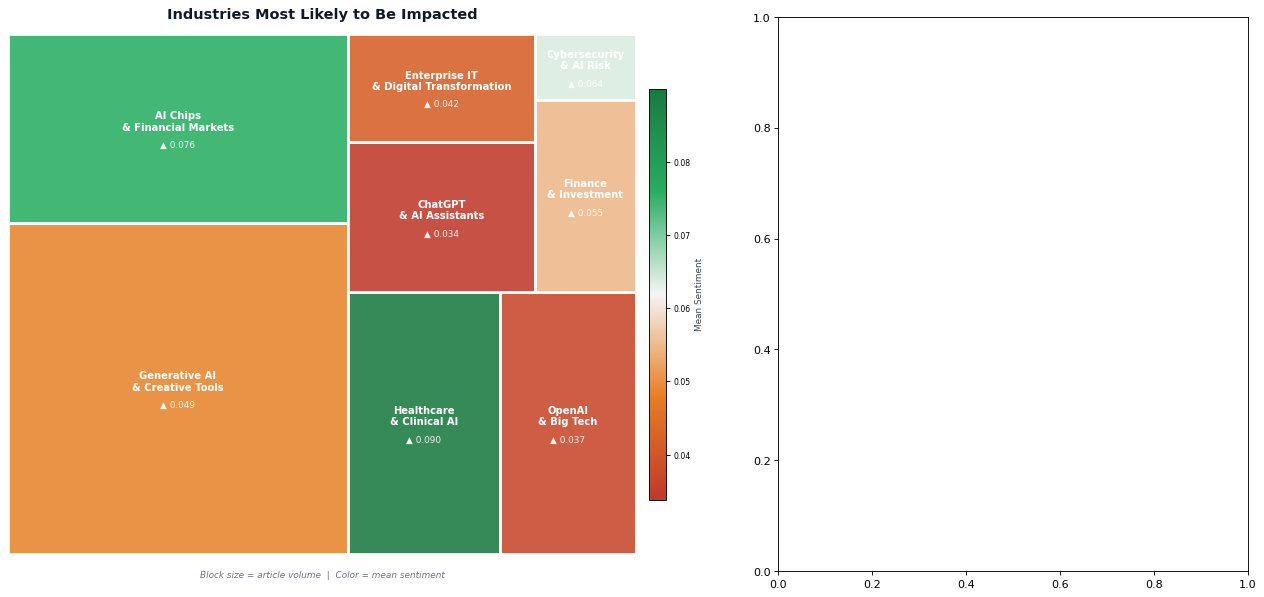

In [19]:
# ── CELL 17b: Treemap + Lollipop ──────────────────────────────
import squarify
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.colors as mcolors
import matplotlib
import numpy as np

matplotlib.rcParams['figure.dpi'] = 80
plt.rcParams['path.simplify'] = True
plt.rcParams['path.simplify_threshold'] = 1.0

NOISE_INDUSTRIES = {"Outlier / Unclustered", "Other / Mixed"}

# ── Data ───────────────────────────────────────────────────────
df_tree_ind = industry_summary[
    ~industry_summary["industry"].isin(NOISE_INDUSTRIES)
].copy().sort_values("article_count", ascending=False)

plot_orgs = (
    org_summary
    .sort_values("mention_count", ascending=False)
    .head(15)
    .sort_values("mean_sentiment")
    .copy()
    .reset_index(drop=True)
)

# ── Colormap — swap yellow band to teal ────────────────────────
from matplotlib.colors import LinearSegmentedColormap
custom_cmap = LinearSegmentedColormap.from_list(
    "rg_notyellow",
    ["#c0392b", "#e67e22", "#f5f5f5", "#27ae60", "#1a7a40"],
    N=256
)
sent_min = df_tree_ind["mean_compound"].min()
sent_max = df_tree_ind["mean_compound"].max()

def sentiment_to_color(val, alpha=0.88):
    norm = (val - sent_min) / (sent_max - sent_min + 1e-9)
    rgba = list(custom_cmap(norm))
    rgba[3] = alpha
    return rgba

# ── Figure ─────────────────────────────────────────────────────
fig, (ax_tree, ax_lol) = plt.subplots(
    1, 2,
    figsize=(20, 9),
    gridspec_kw={"width_ratios": [1.4, 1]}
)

# ══════════════════════════════════════════════════════════════
# PANEL 1 — TREEMAP (articles count removed, sentiment only)
# ══════════════════════════════════════════════════════════════
ax_tree.set_aspect("equal")
ax_tree.axis("off")

sizes  = df_tree_ind["article_count"].values.astype(float)
colors = [sentiment_to_color(s) for s in df_tree_ind["mean_compound"]]

rects = squarify.squarify(
    squarify.normalize_sizes(sizes, 700, 580),
    x=0, y=0, dx=700, dy=580
)

for rect, (_, row), color in zip(rects, df_tree_ind.iterrows(), colors):
    x, y, w, h = rect["x"], rect["y"], rect["dx"], rect["dy"]

    ax_tree.add_patch(plt.Rectangle(
        (x, y), w, h,
        facecolor=color, edgecolor="white", linewidth=2.5
    ))

    if w < 60 or h < 40:
        continue

    short = row["industry"].replace(" & ", "\n& ")

    # Industry name — centered
    ax_tree.text(
        x + w / 2, y + h / 2 + 8,
        short,
        ha="center", va="center",
        fontsize=9, fontweight="700", color="white"
    )

    # Sentiment score only (no article count)
    if h > 65:
        direction = "▲" if row["mean_compound"] > 0.01 else "▼" if row["mean_compound"] < -0.01 else "●"
        ax_tree.text(
            x + w / 2, y + h / 2 - 18,
            f"{direction} {row['mean_compound']:.3f}",
            ha="center", va="center",
            fontsize=8, color="white", alpha=0.9
        )

ax_tree.set_xlim(0, 700)
ax_tree.set_ylim(0, 580)
ax_tree.set_title(
    "Industries Most Likely to Be Impacted",
    fontsize=13, fontweight="700", color="#111827", pad=14
)
ax_tree.text(
    350, -26,
    "Block size = article volume  |  Color = mean sentiment",
    ha="center", fontsize=8, color="#6b7280", style="italic"
)

sm = plt.cm.ScalarMappable(
    cmap=custom_cmap,
    norm=mcolors.Normalize(vmin=sent_min, vmax=sent_max)
)
sm.set_array([])
cbar = fig.colorbar(sm, ax=ax_tree, orientation="vertical",
                    fraction=0.025, pad=0.02, aspect=25)
cbar.set_label("Mean Sentiment", fontsize=8, color="#374151")
cbar.ax.tick_params(labelsize=7)



In [22]:
!pip install adjustText


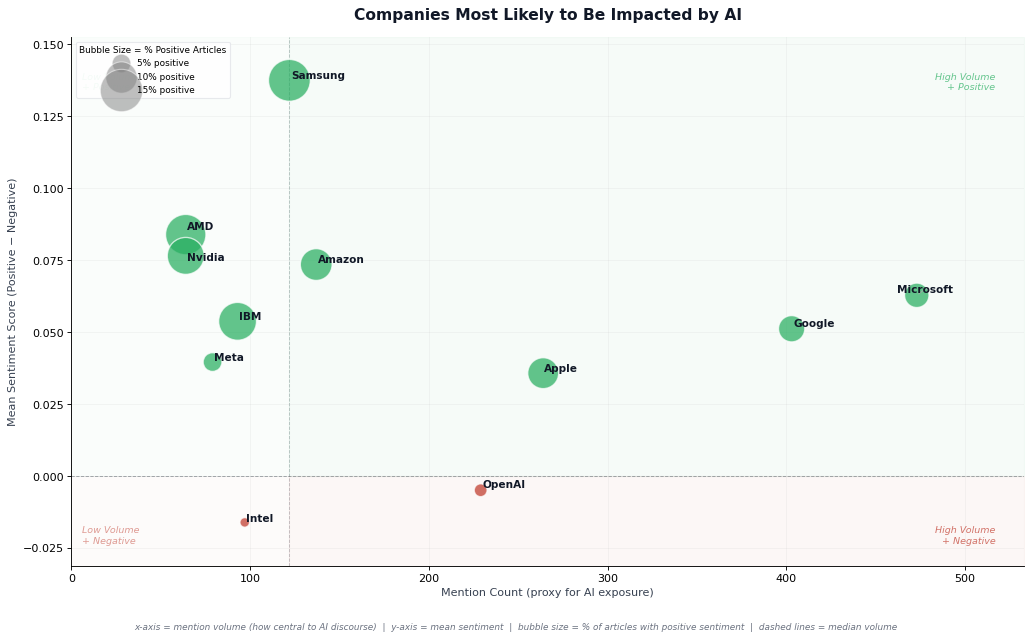

In [23]:
# ── CELL 18b: Company Impact Bubble Chart ─────────────────────
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
from adjustText import adjust_text

fig, ax = plt.subplots(figsize=(13, 8))

plot_clean = org_summary_clean.copy()

# ── Bubble size scaled by % positive ──────────────────────────
size_scale = 25
sizes = (plot_clean["pct_positive"] ** 1.5) * size_scale

# ── Color by sentiment direction ──────────────────────────────
colors = [
    "#27ae60" if s > 0.01
    else "#c0392b" if s < -0.001
    else "#95a5a6"
    for s in plot_clean["mean_sentiment"]
]

scatter = ax.scatter(
    plot_clean["mention_count"],
    plot_clean["mean_sentiment"],
    s=sizes,
    c=colors,
    alpha=0.72,
    edgecolors="white",
    linewidths=1.2,
    zorder=3
)

# ── Company labels ─────────────────────────────────────────────
texts = []
for _, row in plot_clean.iterrows():
    texts.append(ax.text(
        row["mention_count"],
        row["mean_sentiment"],
        row["organization"],
        fontsize=9.5, fontweight="600",
        color="#111827", zorder=5
    ))

adjust_text(
    texts, ax=ax,
    arrowprops=dict(arrowstyle="-", color="#aaa", lw=0.7),
    expand_points=(2.2, 2.2),
    expand_text=(1.8, 1.8)
)

# ── Reference lines ────────────────────────────────────────────
ax.axhline(0, color="#374151", linewidth=0.8,
           linestyle="--", alpha=0.5, zorder=1)
ax.axvline(plot_clean["mention_count"].median(),
           color="#374151", linewidth=0.8,
           linestyle="--", alpha=0.3, zorder=1)

# ── Quadrant shading ───────────────────────────────────────────
x_mid  = plot_clean["mention_count"].median()
y_max  = plot_clean["mean_sentiment"].max() + 0.015
y_min  = plot_clean["mean_sentiment"].min() - 0.015
x_max  = plot_clean["mention_count"].max()  + 60
x_min  = 0

ax.fill_between([x_mid, x_max], 0,  y_max, alpha=0.04, color="#27ae60")  # high vol + positive
ax.fill_between([x_mid, x_max], y_min, 0,  alpha=0.04, color="#c0392b")  # high vol + negative
ax.fill_between([x_min, x_mid], 0,  y_max, alpha=0.02, color="#27ae60")  # low vol + positive
ax.fill_between([x_min, x_mid], y_min, 0,  alpha=0.02, color="#c0392b")  # low vol + negative

# ── Quadrant labels ────────────────────────────────────────────
ax.text(x_max * 0.97, y_max * 0.88,
        "High Volume\n+ Positive",
        ha="right", fontsize=8.5,
        color="#27ae60", alpha=0.7, style="italic")
ax.text(x_max * 0.97, y_min * 0.75,
        "High Volume\n+ Negative",
        ha="right", fontsize=8.5,
        color="#c0392b", alpha=0.7, style="italic")
ax.text(x_mid * 0.05, y_max * 0.88,
        "Low Volume\n+ Positive",
        ha="left", fontsize=8.5,
        color="#27ae60", alpha=0.5, style="italic")
ax.text(x_mid * 0.05, y_min * 0.75,
        "Low Volume\n+ Negative",
        ha="left", fontsize=8.5,
        color="#c0392b", alpha=0.5, style="italic")

# ── Bubble size legend ─────────────────────────────────────────
for pct, label in [(5, "5% positive"), (10, "10% positive"), (15, "15% positive")]:
    ax.scatter([], [], s=(pct ** 1.5) * size_scale,
               color="gray", alpha=0.5, label=label,
               edgecolors="white", linewidths=1)
ax.legend(
    title="Bubble Size = % Positive Articles",
    title_fontsize=8, fontsize=8,
    loc="upper left", framealpha=0.9,
    edgecolor="#e5e7eb"
)

# ── Axes + labels ──────────────────────────────────────────────
ax.set_xlim(x_min, x_max)
ax.set_ylim(y_min, y_max)
ax.set_xlabel("Mention Count (proxy for AI exposure)",
              fontsize=10, color="#374151")
ax.set_ylabel("Mean Sentiment Score (Positive − Negative)",
              fontsize=10, color="#374151")
ax.set_title(
    "Companies Most Likely to Be Impacted by AI",
    fontsize=14, fontweight="700", color="#111827", pad=16
)
ax.spines[["top", "right"]].set_visible(False)
ax.grid(alpha=0.12)

fig.text(
    0.5, 0.01,
    "x-axis = mention volume (how central to AI discourse)  |  "
    "y-axis = mean sentiment  |  "
    "bubble size = % of articles with positive sentiment  |  "
    "dashed lines = median volume",
    ha="center", fontsize=8, color="#6b7280", style="italic"
)

plt.tight_layout(rect=[0, 0.04, 1, 1])
plt.savefig(BASE + "company_impact_bubble.png", dpi=150, bbox_inches="tight")
plt.show()

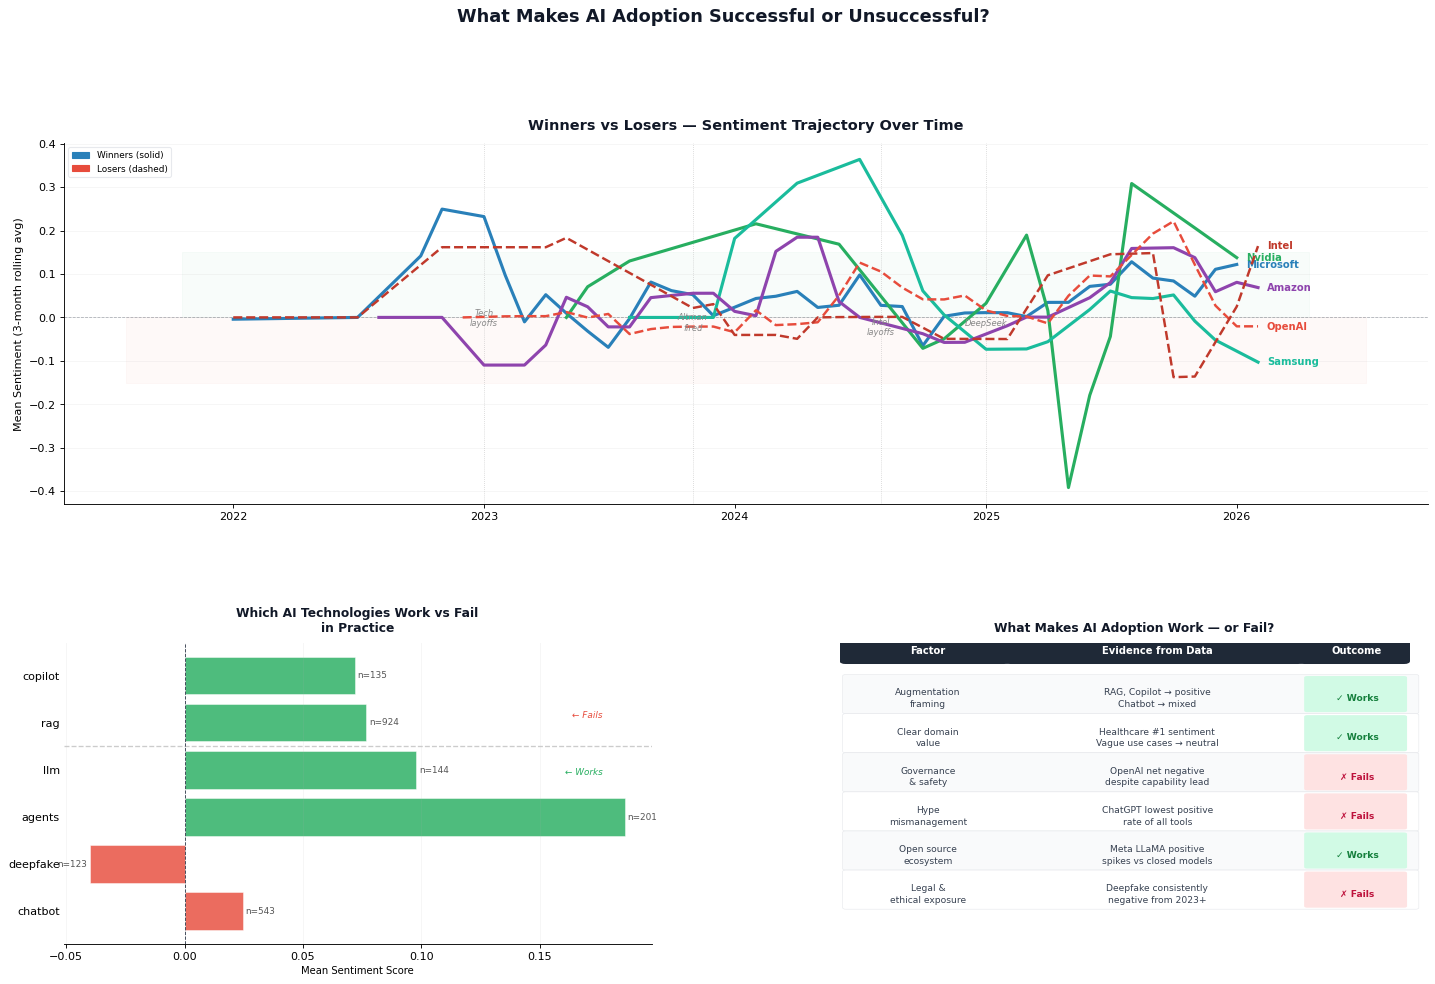

In [24]:
# ── CELL 19: What Makes AI Adoption Work or Fail ──────────────
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.patches as mpatches
import pandas as pd
import numpy as np

# ══════════════════════════════════════════════════════════════
# DATA PREP
# ══════════════════════════════════════════════════════════════

# ── Winners vs Losers ──────────────────────────────────────────
WINNERS = ["Microsoft", "Nvidia", "Samsung", "Amazon"]
LOSERS  = ["OpenAI", "Intel"]
TRACK   = WINNERS + LOSERS

org_time = (
    df_merged[["url", "orgs"]]
    .explode("orgs").rename(columns={"orgs": "organization"})
)
org_time = org_time[org_time["organization"].apply(is_valid_org_strict)]
org_time = org_time.merge(
    df[["url", "sentiment_compound", "date"]], on="url", how="left"
)
org_time["date"] = pd.to_datetime(org_time["date"], errors="coerce")
org_time["year_month"] = org_time["date"].dt.to_period("M")

# ── Technology sentiment ───────────────────────────────────────
TECH_COMPARE = {
    "Works":  ["rag", "copilot", "llm", "agents"],
    "Fails":  ["chatbot", "deepfake"],
}
all_tech = [t for grp in TECH_COMPARE.values() for t in grp]

tech_plot = (
    tech_summary[tech_summary["technology"].isin(all_tech)]
    .copy()
)
tech_plot["group"] = tech_plot["technology"].apply(
    lambda t: "Works" if t in TECH_COMPARE["Works"] else "Fails"
)
tech_plot = tech_plot.sort_values(["group", "mean_sentiment"], ascending=[True, False])

# ══════════════════════════════════════════════════════════════
# FIGURE — 3 panels
# ══════════════════════════════════════════════════════════════
fig = plt.figure(figsize=(22, 13))
gs  = gridspec.GridSpec(
    2, 2,
    figure=fig,
    hspace=0.42, wspace=0.32,
    height_ratios=[1.2, 1]
)

ax_traj  = fig.add_subplot(gs[0, :])   # top full width — trajectory
ax_tech  = fig.add_subplot(gs[1, 0])   # bottom left — tech bar
ax_table = fig.add_subplot(gs[1, 1])   # bottom right — 2x2 table

WINNER_COLORS = {
    "Microsoft": "#2980b9",
    "Nvidia":    "#27ae60",
    "Samsung":   "#1abc9c",
    "Amazon":    "#8e44ad",
}
LOSER_COLORS = {
    "OpenAI": "#e74c3c",
    "Intel":  "#c0392b",
}
ALL_COLORS = {**WINNER_COLORS, **LOSER_COLORS}

# ══════════════════════════════════════════════════════════════
# PANEL 1 — TRAJECTORY: Winners vs Losers
# ══════════════════════════════════════════════════════════════
for org in TRACK:
    df_org = org_time[org_time["organization"] == org].copy()
    ts = df_org.groupby("year_month")["sentiment_compound"].mean().reset_index()
    counts = df_org.groupby("year_month").size().reset_index(name="n")
    ts = ts.merge(counts, on="year_month").query("n >= 3")
    if len(ts) < 4: continue
    ts["year_month_dt"] = ts["year_month"].dt.to_timestamp()
    ts["smoothed"] = ts["sentiment_compound"].rolling(3, min_periods=1).mean()

    lw    = 2.8 if org in WINNERS else 2.2
    ls    = "solid" if org in WINNERS else "dashed"
    color = ALL_COLORS[org]

    ax_traj.plot(
        ts["year_month_dt"], ts["smoothed"],
        color=color, linewidth=lw,
        linestyle=ls, label=org, zorder=3
    )
    # End label
    last = ts.iloc[-1]
    ax_traj.annotate(
        org,
        xy=(last["year_month_dt"], last["smoothed"]),
        xytext=(8, 0), textcoords="offset points",
        fontsize=9, fontweight="700",
        color=color, va="center"
    )

ax_traj.axhline(0, color="#374151", linewidth=0.7,
                linestyle="--", alpha=0.4)
ax_traj.fill_between(
    ax_traj.get_xlim(), 0, 0.15,
    alpha=0.03, color="#27ae60"
)
ax_traj.fill_between(
    ax_traj.get_xlim(), -0.15, 0,
    alpha=0.03, color="#e74c3c"
)

# Annotate key events
events = [
    ("2023-01", -0.02, "Tech\nlayoffs"),
    ("2023-11", -0.03, "Altman\nfired"),
    ("2024-08", -0.04, "Intel\nlayoffs"),
    ("2025-01", -0.02, "DeepSeek"),
]
for date_str, y_pos, label in events:
    dt = pd.Timestamp(date_str)
    ax_traj.axvline(dt, color="#aaa", linewidth=0.7,
                    linestyle=":", alpha=0.6, zorder=1)
    ax_traj.text(dt, y_pos, label, fontsize=7.5,
                 color="#888", ha="center", style="italic")

ax_traj.set_ylabel("Mean Sentiment (3-month rolling avg)", fontsize=10)
ax_traj.set_title(
    "Winners vs Losers — Sentiment Trajectory Over Time",
    fontsize=13, fontweight="700", color="#111827", pad=12
)
ax_traj.spines[["top", "right"]].set_visible(False)
ax_traj.grid(axis="y", alpha=0.12)

winner_patch = mpatches.Patch(color="#2980b9", label="Winners (solid)")
loser_patch  = mpatches.Patch(color="#e74c3c", label="Losers (dashed)")
ax_traj.legend(
    handles=[winner_patch, loser_patch],
    fontsize=8, loc="upper left",
    framealpha=0.9, edgecolor="#e5e7eb"
)

# ══════════════════════════════════════════════════════════════
# PANEL 2 — TECH BAR: Works vs Fails
# ══════════════════════════════════════════════════════════════
bar_colors = [
    "#27ae60" if g == "Works" else "#e74c3c"
    for g in tech_plot["group"]
]
bars = ax_tech.barh(
    tech_plot["technology"],
    tech_plot["mean_sentiment"],
    color=bar_colors, alpha=0.82,
    edgecolor="white", linewidth=0.5
)

for bar, (_, row) in zip(bars, tech_plot.iterrows()):
    x   = bar.get_width()
    off = 0.0012 if x >= 0 else -0.0012
    ha  = "left"  if x >= 0 else "right"
    ax_tech.text(
        x + off, bar.get_y() + bar.get_height() / 2,
        f"n={int(row['mention_count'])}",
        va="center", ha=ha, fontsize=8, color="#555"
    )

# Group divider line
works_count = (tech_plot["group"] == "Works").sum()
ax_tech.axhline(
    works_count - 0.5,
    color="#ccc", linewidth=1.2, linestyle="--"
)
ax_tech.text(
    tech_plot["mean_sentiment"].max() * 0.95,
    works_count + 0.1, "← Fails",
    fontsize=8, color="#e74c3c",
    style="italic", ha="right"
)
ax_tech.text(
    tech_plot["mean_sentiment"].max() * 0.95,
    works_count - 1.1, "← Works",
    fontsize=8, color="#27ae60",
    style="italic", ha="right"
)

ax_tech.axvline(0, color="#374151", linewidth=0.8, linestyle="--")
ax_tech.set_xlabel("Mean Sentiment Score", fontsize=9)
ax_tech.set_title(
    "Which AI Technologies Work vs Fail\nin Practice",
    fontsize=11, fontweight="700", color="#111827", pad=10
)
ax_tech.spines[["top", "right", "left"]].set_visible(False)
ax_tech.tick_params(axis="y", length=0, labelsize=10)
ax_tech.grid(axis="x", alpha=0.12)

# ══════════════════════════════════════════════════════════════
# PANEL 3 — 2x2 FRAMEWORK TABLE
# ══════════════════════════════════════════════════════════════
ax_table.axis("off")

table_data = [
    # Factor, Evidence from data, Outcome
    ["Augmentation\nframing",    "RAG, Copilot → positive\nChatbot → mixed",         "✓ Works"],
    ["Clear domain\nvalue",      "Healthcare #1 sentiment\nVague use cases → neutral", "✓ Works"],
    ["Governance\n& safety",     "OpenAI net negative\ndespite capability lead",       "✗ Fails"],
    ["Hype\nmismanagement",      "ChatGPT lowest positive\nrate of all tools",         "✗ Fails"],
    ["Open source\necosystem",   "Meta LLaMA positive\nspikes vs closed models",       "✓ Works"],
    ["Legal &\nethical exposure","Deepfake consistently\nnegative from 2023+",          "✗ Fails"],
]

col_labels  = ["Factor", "Evidence from Data", "Outcome"]
col_widths  = [0.28, 0.50, 0.18]
row_height  = 0.13
start_y     = 0.93
header_y    = start_y + 0.05

# Header
for j, (label, xw) in enumerate(zip(col_labels, col_widths)):
    x = sum(col_widths[:j]) + 0.02
    ax_table.add_patch(mpatches.FancyBboxPatch(
        (x - 0.01, header_y - 0.04), xw - 0.01, 0.07,
        boxstyle="round,pad=0.01",
        facecolor="#1f2937", edgecolor="none"
    ))
    ax_table.text(
        x + (xw - 0.02) / 2, header_y - 0.005,
        label, ha="center", va="center",
        fontsize=9, fontweight="700", color="white"
    )

# Rows
for i, row in enumerate(table_data):
    y = start_y - (i + 1) * row_height
    bg = "#f9fafb" if i % 2 == 0 else "#ffffff"
    outcome_color = "#d1fae5" if "✓" in row[2] else "#fee2e2"

    ax_table.add_patch(mpatches.FancyBboxPatch(
        (0.01, y - 0.03), 0.97, row_height - 0.01,
        boxstyle="round,pad=0.005",
        facecolor=bg, edgecolor="#e5e7eb", linewidth=0.5
    ))

    for j, (cell, xw) in enumerate(zip(row, col_widths)):
        x = sum(col_widths[:j]) + 0.02
        cell_bg = outcome_color if j == 2 else bg
        if j == 2:
            ax_table.add_patch(mpatches.FancyBboxPatch(
                (x - 0.005, y - 0.025), xw - 0.015, row_height - 0.02,
                boxstyle="round,pad=0.005",
                facecolor=cell_bg, edgecolor="none"
            ))
        color = "#15803d" if (j == 2 and "✓" in cell) else \
                "#be123c" if (j == 2 and "✗" in cell) else "#374151"
        fw = "700" if j == 2 else "400"
        ax_table.text(
            x + (xw - 0.02) / 2, y + row_height / 2 - 0.05,
            cell, ha="center", va="center",
            fontsize=8.2, color=color, fontweight=fw,
            linespacing=1.4
        )

ax_table.set_xlim(0, 1)
ax_table.set_ylim(0, 1)
ax_table.set_title(
    "What Makes AI Adoption Work — or Fail?",
    fontsize=11, fontweight="700", color="#111827", pad=10
)

# ── Shared title ───────────────────────────────────────────────
fig.suptitle(
    "What Makes AI Adoption Successful or Unsuccessful?",
    fontsize=16, fontweight="700", color="#111827", y=1.01
)

plt.savefig(BASE + "ai_adoption_factors.png", dpi=130, bbox_inches="tight")
plt.show()

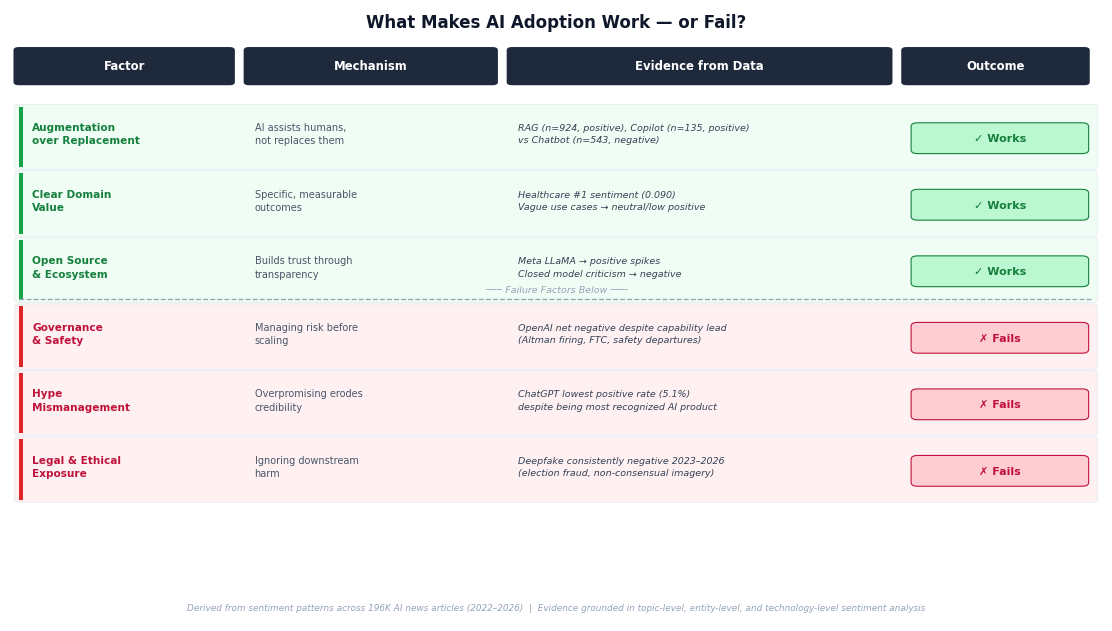

In [25]:
# ── CELL 19b: Standalone Adoption Framework Table ─────────────
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

fig, ax = plt.subplots(figsize=(14, 8))
ax.axis("off")
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)

# ── Table data ─────────────────────────────────────────────────
# Factor | Mechanism | Evidence from your data | Outcome
rows = [
    (
        "Augmentation\nover Replacement",
        "AI assists humans,\nnot replaces them",
        "RAG (n=924, positive), Copilot (n=135, positive)\nvs Chatbot (n=543, negative)",
        "✓ Works"
    ),
    (
        "Clear Domain\nValue",
        "Specific, measurable\noutcomes",
        "Healthcare #1 sentiment (0.090)\nVague use cases → neutral/low positive",
        "✓ Works"
    ),
    (
        "Open Source\n& Ecosystem",
        "Builds trust through\ntransparency",
        "Meta LLaMA → positive spikes\nClosed model criticism → negative",
        "✓ Works"
    ),
    (
        "Governance\n& Safety",
        "Managing risk before\nscaling",
        "OpenAI net negative despite capability lead\n(Altman firing, FTC, safety departures)",
        "✗ Fails"
    ),
    (
        "Hype\nMismanagement",
        "Overpromising erodes\ncredibility",
        "ChatGPT lowest positive rate (5.1%)\ndespite being most recognized AI product",
        "✗ Fails"
    ),
    (
        "Legal & Ethical\nExposure",
        "Ignoring downstream\nharm",
        "Deepfake consistently negative 2023–2026\n(election fraud, non-consensual imagery)",
        "✗ Fails"
    ),
]

# ── Layout constants ───────────────────────────────────────────
COL_X      = [0.01, 0.22, 0.46, 0.82]
COL_W      = [0.20, 0.23, 0.35, 0.17]
COL_LABELS = ["Factor", "Mechanism", "Evidence from Data", "Outcome"]
ROW_H      = 0.108
HEADER_Y   = 0.91
START_Y    = 0.84

# ── Header ─────────────────────────────────────────────────────
for j, (label, x, w) in enumerate(zip(COL_LABELS, COL_X, COL_W)):
    ax.add_patch(mpatches.FancyBboxPatch(
        (x, HEADER_Y - 0.032), w - 0.008, 0.052,
        boxstyle="round,pad=0.005",
        facecolor="#1e293b", edgecolor="none", zorder=2
    ))
    ax.text(
        x + (w - 0.008) / 2, HEADER_Y - 0.005,
        label, ha="center", va="center",
        fontsize=10.5, fontweight="700", color="white", zorder=3
    )

# ── Section divider between Works and Fails ───────────────────
divider_y = START_Y - 3 * ROW_H + 0.01
ax.plot([0.01, 0.99], [divider_y, divider_y],
        color="#94a3b8", linewidth=1.2,
        linestyle="--", zorder=4)
ax.text(0.5, divider_y + 0.012, "─── Failure Factors Below ───",
        ha="center", fontsize=8.5,
        color="#94a3b8", style="italic", zorder=4)

# ── Rows ───────────────────────────────────────────────────────
for i, (factor, mechanism, evidence, outcome) in enumerate(rows):
    y = START_Y - i * ROW_H

    is_works = "✓" in outcome
    row_bg   = "#f0fdf4" if is_works else "#fff1f2"
    out_bg   = "#bbf7d0" if is_works else "#fecdd3"
    out_fg   = "#15803d" if is_works else "#be123c"
    factor_fg = "#15803d" if is_works else "#be123c"

    # Row background
    ax.add_patch(mpatches.FancyBboxPatch(
        (0.01, y - ROW_H + 0.008), 0.98, ROW_H - 0.01,
        boxstyle="round,pad=0.004",
        facecolor=row_bg, edgecolor="#e2e8f0",
        linewidth=0.6, zorder=1
    ))

    # Left accent bar
    accent = "#16a34a" if is_works else "#dc2626"
    ax.add_patch(mpatches.FancyBboxPatch(
        (0.01, y - ROW_H + 0.008), 0.004, ROW_H - 0.01,
        boxstyle="square,pad=0",
        facecolor=accent, edgecolor="none", zorder=2
    ))

    # Factor
    ax.text(
        COL_X[0] + 0.012, y - ROW_H / 2 + 0.008,
        factor, ha="left", va="center",
        fontsize=9.5, fontweight="700",
        color=factor_fg, linespacing=1.4, zorder=3
    )

    # Mechanism
    ax.text(
        COL_X[1] + 0.005, y - ROW_H / 2 + 0.008,
        mechanism, ha="left", va="center",
        fontsize=8.8, color="#475569",
        linespacing=1.4, zorder=3
    )

    # Evidence
    ax.text(
        COL_X[2] + 0.005, y - ROW_H / 2 + 0.008,
        evidence, ha="left", va="center",
        fontsize=8.5, color="#334155",
        linespacing=1.45, zorder=3,
        style="italic"
    )

    # Outcome badge
    badge_x = COL_X[3] + 0.01
    badge_w = COL_W[3] - 0.02
    ax.add_patch(mpatches.FancyBboxPatch(
        (badge_x, y - ROW_H / 2 - 0.018),
        badge_w, 0.038,
        boxstyle="round,pad=0.006",
        facecolor=out_bg, edgecolor=out_fg,
        linewidth=1.0, zorder=3
    ))
    ax.text(
        badge_x + badge_w / 2, y - ROW_H / 2 + 0.001,
        outcome, ha="center", va="center",
        fontsize=10, fontweight="700",
        color=out_fg, zorder=4
    )

# ── Title + caption ────────────────────────────────────────────
ax.text(
    0.5, 0.975,
    "What Makes AI Adoption Work — or Fail?",
    ha="center", va="center",
    fontsize=15, fontweight="700", color="#0f172a"
)
ax.text(
    0.5, 0.025,
    "Derived from sentiment patterns across 196K AI news articles (2022–2026)  |  "
    "Evidence grounded in topic-level, entity-level, and technology-level sentiment analysis",
    ha="center", va="center",
    fontsize=8, color="#94a3b8", style="italic"
)

plt.tight_layout()
plt.savefig(BASE + "adoption_framework.png", dpi=150, bbox_inches="tight")
plt.show()

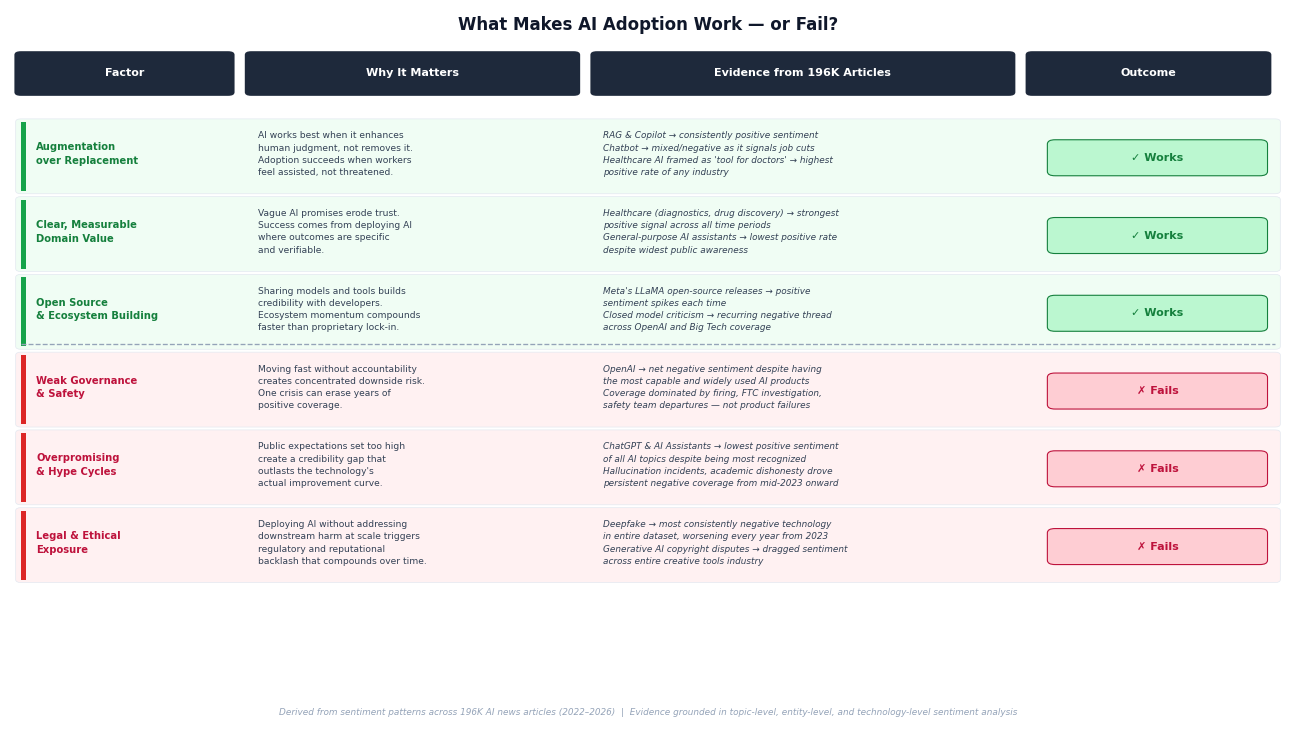

In [31]:
# ── CELL 19c: Adoption Framework Table — elaborated ───────────
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

fig, ax = plt.subplots(figsize=(16, 9))
ax.axis("off")
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)

rows = [
    (
        "Augmentation\nover Replacement",
        "AI works best when it enhances\nhuman judgment, not removes it.\nAdoption succeeds when workers\nfeel assisted, not threatened.",
        "RAG & Copilot → consistently positive sentiment\n"
        "Chatbot → mixed/negative as it signals job cuts\n"
        "Healthcare AI framed as 'tool for doctors' → highest\n"
        "positive rate of any industry",
        "✓ Works"
    ),
    (
        "Clear, Measurable\nDomain Value",
        "Vague AI promises erode trust.\nSuccess comes from deploying AI\nwhere outcomes are specific\nand verifiable.",
        "Healthcare (diagnostics, drug discovery) → strongest\n"
        "positive signal across all time periods\n"
        "General-purpose AI assistants → lowest positive rate\n"
        "despite widest public awareness",
        "✓ Works"
    ),
    (
        "Open Source\n& Ecosystem Building",
        "Sharing models and tools builds\ncredibility with developers.\nEcosystem momentum compounds\nfaster than proprietary lock-in.",
        "Meta's LLaMA open-source releases → positive\n"
        "sentiment spikes each time\n"
        "Closed model criticism → recurring negative thread\n"
        "across OpenAI and Big Tech coverage",
        "✓ Works"
    ),
    (
        "Weak Governance\n& Safety",
        "Moving fast without accountability\ncreates concentrated downside risk.\nOne crisis can erase years of\npositive coverage.",
        "OpenAI → net negative sentiment despite having\n"
        "the most capable and widely used AI products\n"
        "Coverage dominated by firing, FTC investigation,\n"
        "safety team departures — not product failures",
        "✗ Fails"
    ),
    (
        "Overpromising\n& Hype Cycles",
        "Public expectations set too high\ncreate a credibility gap that\noutlasts the technology's\nactual improvement curve.",
        "ChatGPT & AI Assistants → lowest positive sentiment\n"
        "of all AI topics despite being most recognized\n"
        "Hallucination incidents, academic dishonesty drove\n"
        "persistent negative coverage from mid-2023 onward",
        "✗ Fails"
    ),
    (
        "Legal & Ethical\nExposure",
        "Deploying AI without addressing\ndownstream harm at scale triggers\nregulatory and reputational\nbacklash that compounds over time.",
        "Deepfake → most consistently negative technology\n"
        "in entire dataset, worsening every year from 2023\n"
        "Generative AI copyright disputes → dragged sentiment\n"
        "across entire creative tools industry",
        "✗ Fails"
    ),
]

# ── Layout ─────────────────────────────────────────────────────
COL_X      = [0.01,  0.19,  0.46,  0.80]
COL_W      = [0.17,  0.26,  0.33,  0.19]
COL_LABELS = ["Factor", "Why It Matters", "Evidence from 196K Articles", "Outcome"]
ROW_H      = 0.108
HEADER_Y   = 0.915
START_Y    = 0.845

# ── Header ─────────────────────────────────────────────────────
for label, x, w in zip(COL_LABELS, COL_X, COL_W):
    ax.add_patch(mpatches.FancyBboxPatch(
        (x, HEADER_Y - 0.032), w - 0.008, 0.052,
        boxstyle="round,pad=0.005",
        facecolor="#1e293b", edgecolor="none", zorder=2
    ))
    ax.text(
        x + (w - 0.008) / 2, HEADER_Y - 0.005,
        label, ha="center", va="center",
        fontsize=10, fontweight="700",
        color="white", zorder=3
    )

# ── Divider between Works / Fails ─────────────────────────────
divider_y = START_Y - 3 * ROW_H + 0.012
ax.plot([0.01, 0.99], [divider_y, divider_y],
        color="#94a3b8", linewidth=1.2,
        linestyle="--", zorder=4)
# ax.text(
#     0.7, divider_y + 0.011,
#     "─────────────────  Failure Factors  ─────────────────",
#     ha="center", fontsize=8.5,
#     color="#94a3b8", style="italic", zorder=4
# )

# ── Rows ───────────────────────────────────────────────────────
for i, (factor, mechanism, evidence, outcome) in enumerate(rows):
    y        = START_Y - i * ROW_H
    is_works = "✓" in outcome

    row_bg   = "#f0fdf4" if is_works else "#fff1f2"
    out_bg   = "#bbf7d0" if is_works else "#fecdd3"
    out_fg   = "#15803d" if is_works else "#be123c"
    fact_fg  = "#15803d" if is_works else "#be123c"
    accent   = "#16a34a" if is_works else "#dc2626"

    # Row bg
    ax.add_patch(mpatches.FancyBboxPatch(
        (0.01, y - ROW_H + 0.009), 0.98, ROW_H - 0.012,
        boxstyle="round,pad=0.004",
        facecolor=row_bg, edgecolor="#e2e8f0",
        linewidth=0.6, zorder=1
    ))

    # Left accent bar
    ax.add_patch(mpatches.FancyBboxPatch(
        (0.01, y - ROW_H + 0.009), 0.004, ROW_H - 0.012,
        boxstyle="square,pad=0",
        facecolor=accent, edgecolor="none", zorder=2
    ))

    # Factor
    ax.text(
        COL_X[0] + 0.012, y - ROW_H / 2 + 0.006,
        factor, ha="left", va="center",
        fontsize=9, fontweight="700",
        color=fact_fg, linespacing=1.45, zorder=3
    )

    # Mechanism
    ax.text(
        COL_X[1] + 0.005, y - ROW_H / 2 + 0.006,
        mechanism, ha="left", va="center",
        fontsize=8.2, color="#334155",
        linespacing=1.45, zorder=3
    )

    # Evidence
    ax.text(
        COL_X[2] + 0.005, y - ROW_H / 2 + 0.006,
        evidence, ha="left", va="center",
        fontsize=8, color="#334155",
        linespacing=1.45, zorder=3,
        style="italic"
    )

    # Outcome badge
    bx = COL_X[3] + 0.018
    bw = COL_W[3] - 0.03
    ax.add_patch(mpatches.FancyBboxPatch(
        (bx, y - ROW_H / 2 - 0.018),
        bw, 0.038,
        boxstyle="round,pad=0.006",
        facecolor=out_bg, edgecolor=out_fg,
        linewidth=1.0, zorder=3
    ))
    ax.text(
        bx + bw / 2, y - ROW_H / 2 + 0.001,
        outcome, ha="center", va="center",
        fontsize=10, fontweight="700",
        color=out_fg, zorder=4
    )

# ── Title + caption ────────────────────────────────────────────
ax.text(
    0.5, 0.976,
    "What Makes AI Adoption Work — or Fail?",
    ha="center", va="center",
    fontsize=15, fontweight="700", color="#0f172a"
)
ax.text(
    0.5, 0.022,
    "Derived from sentiment patterns across 196K AI news articles (2022–2026)  |  "
    "Evidence grounded in topic-level, entity-level, and technology-level sentiment analysis",
    ha="center", va="center",
    fontsize=8, color="#94a3b8", style="italic"
)

plt.subplots_adjust(left=0, right=1, top=1, bottom=0)
plt.savefig(BASE + "adoption_framework.png", dpi=120, bbox_inches="tight")
plt.show()

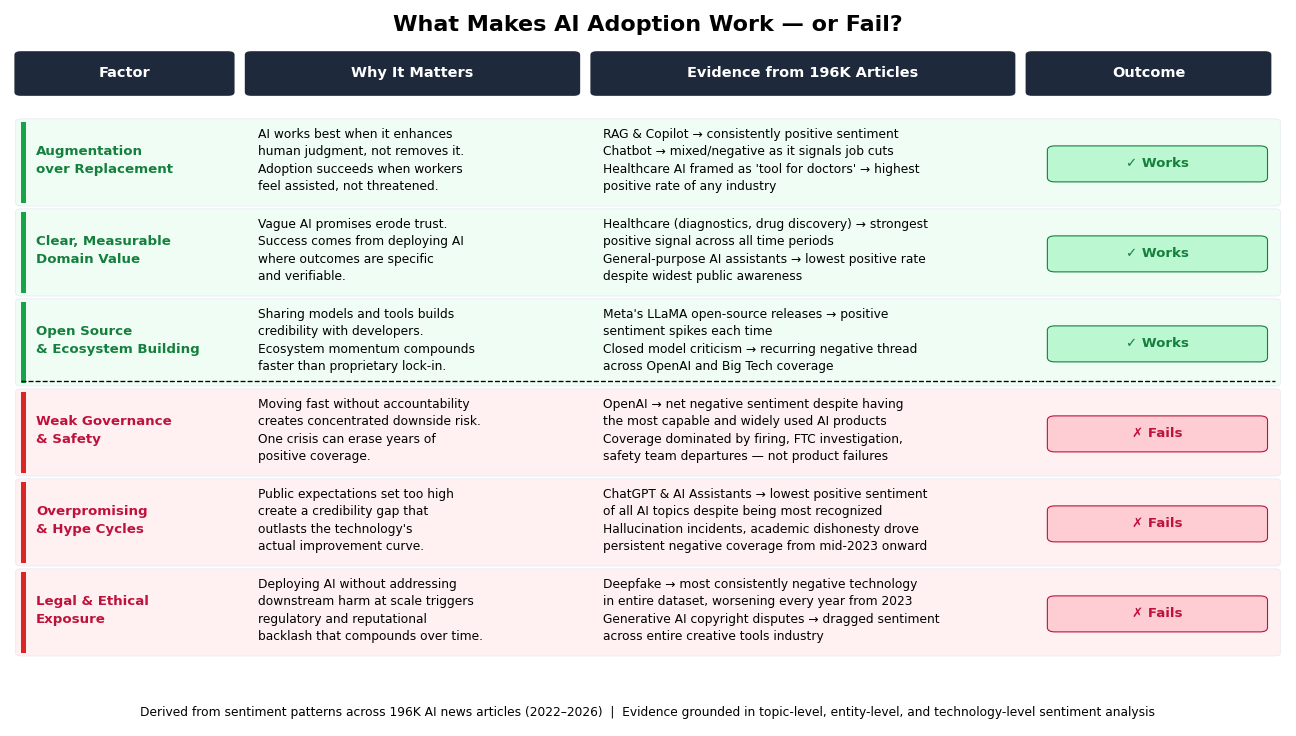

In [32]:
# ── CELL 19c: Adoption Framework Table — elaborated ───────────
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

fig, ax = plt.subplots(figsize=(16, 9))
ax.axis("off")
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)

rows = [
    (
        "Augmentation\nover Replacement",
        "AI works best when it enhances\nhuman judgment, not removes it.\nAdoption succeeds when workers\nfeel assisted, not threatened.",
        "RAG & Copilot → consistently positive sentiment\n"
        "Chatbot → mixed/negative as it signals job cuts\n"
        "Healthcare AI framed as 'tool for doctors' → highest\n"
        "positive rate of any industry",
        "✓ Works"
    ),
    (
        "Clear, Measurable\nDomain Value",
        "Vague AI promises erode trust.\nSuccess comes from deploying AI\nwhere outcomes are specific\nand verifiable.",
        "Healthcare (diagnostics, drug discovery) → strongest\n"
        "positive signal across all time periods\n"
        "General-purpose AI assistants → lowest positive rate\n"
        "despite widest public awareness",
        "✓ Works"
    ),
    (
        "Open Source\n& Ecosystem Building",
        "Sharing models and tools builds\ncredibility with developers.\nEcosystem momentum compounds\nfaster than proprietary lock-in.",
        "Meta's LLaMA open-source releases → positive\n"
        "sentiment spikes each time\n"
        "Closed model criticism → recurring negative thread\n"
        "across OpenAI and Big Tech coverage",
        "✓ Works"
    ),
    (
        "Weak Governance\n& Safety",
        "Moving fast without accountability\ncreates concentrated downside risk.\nOne crisis can erase years of\npositive coverage.",
        "OpenAI → net negative sentiment despite having\n"
        "the most capable and widely used AI products\n"
        "Coverage dominated by firing, FTC investigation,\n"
        "safety team departures — not product failures",
        "✗ Fails"
    ),
    (
        "Overpromising\n& Hype Cycles",
        "Public expectations set too high\ncreate a credibility gap that\noutlasts the technology's\nactual improvement curve.",
        "ChatGPT & AI Assistants → lowest positive sentiment\n"
        "of all AI topics despite being most recognized\n"
        "Hallucination incidents, academic dishonesty drove\n"
        "persistent negative coverage from mid-2023 onward",
        "✗ Fails"
    ),
    (
        "Legal & Ethical\nExposure",
        "Deploying AI without addressing\ndownstream harm at scale triggers\nregulatory and reputational\nbacklash that compounds over time.",
        "Deepfake → most consistently negative technology\n"
        "in entire dataset, worsening every year from 2023\n"
        "Generative AI copyright disputes → dragged sentiment\n"
        "across entire creative tools industry",
        "✗ Fails"
    ),
]

# ── Layout ─────────────────────────────────────────────────────
COL_X      = [0.01,  0.19,  0.46,  0.80]
COL_W      = [0.17,  0.26,  0.33,  0.19]
COL_LABELS = ["Factor", "Why It Matters", "Evidence from 196K Articles", "Outcome"]

ROW_H      = 0.125
HEADER_Y   = 0.915
START_Y    = 0.845

# ── Header ─────────────────────────────────────────────────────
for label, x, w in zip(COL_LABELS, COL_X, COL_W):
    ax.add_patch(mpatches.FancyBboxPatch(
        (x, HEADER_Y - 0.032), w - 0.008, 0.052,
        boxstyle="round,pad=0.005",
        facecolor="#1e293b", edgecolor="none", zorder=2
    ))
    ax.text(
        x + (w - 0.008) / 2, HEADER_Y - 0.005,
        label, ha="center", va="center",
        fontsize=13, fontweight="700",
        color="white", zorder=3
    )

# ── Divider between Works / Fails ─────────────────────────────
divider_y = START_Y - 3 * ROW_H + 0.012
ax.plot([0.01, 0.99], [divider_y, divider_y],
        color="black", linewidth=1.2,
        linestyle="--", zorder=4)

# ── Rows ───────────────────────────────────────────────────────
for i, (factor, mechanism, evidence, outcome) in enumerate(rows):
    y        = START_Y - i * ROW_H
    is_works = "✓" in outcome

    row_bg   = "#f0fdf4" if is_works else "#fff1f2"
    out_bg   = "#bbf7d0" if is_works else "#fecdd3"
    out_fg   = "#15803d" if is_works else "#be123c"
    fact_fg  = "#15803d" if is_works else "#be123c"
    accent   = "#16a34a" if is_works else "#dc2626"

    ax.add_patch(mpatches.FancyBboxPatch(
        (0.01, y - ROW_H + 0.009), 0.98, ROW_H - 0.012,
        boxstyle="round,pad=0.004",
        facecolor=row_bg, edgecolor="#e2e8f0",
        linewidth=0.6, zorder=1
    ))

    ax.add_patch(mpatches.FancyBboxPatch(
        (0.01, y - ROW_H + 0.009), 0.004, ROW_H - 0.012,
        boxstyle="square,pad=0",
        facecolor=accent, edgecolor="none", zorder=2
    ))

    # Factor
    ax.text(
        COL_X[0] + 0.012, y - ROW_H / 2 + 0.006,
        factor, ha="left", va="center",
        fontsize=12, fontweight="700",
        color=fact_fg, linespacing=1.45, zorder=3
    )

    # Mechanism
    ax.text(
        COL_X[1] + 0.005, y - ROW_H / 2 + 0.006,
        mechanism, ha="left", va="center",
        fontsize=11, color="black",
        linespacing=1.45, zorder=3
    )

    # Evidence
    ax.text(
        COL_X[2] + 0.005, y - ROW_H / 2 + 0.006,
        evidence, ha="left", va="center",
        fontsize=11, color="black",
        linespacing=1.45, zorder=3
    )

    # Outcome badge
    bx = COL_X[3] + 0.018
    bw = COL_W[3] - 0.03
    ax.add_patch(mpatches.FancyBboxPatch(
        (bx, y - ROW_H / 2 - 0.018),
        bw, 0.038,
        boxstyle="round,pad=0.006",
        facecolor=out_bg, edgecolor=out_fg,
        linewidth=1.0, zorder=3
    ))
    ax.text(
        bx + bw / 2, y - ROW_H / 2 + 0.001,
        outcome, ha="center", va="center",
        fontsize=12, fontweight="700",
        color=out_fg, zorder=4
    )

# ── Title + caption ────────────────────────────────────────────
ax.text(
    0.5, 0.976,
    "What Makes AI Adoption Work — or Fail?",
    ha="center", va="center",
    fontsize=20, fontweight="700", color="black"
)

ax.text(
    0.5, 0.022,
    "Derived from sentiment patterns across 196K AI news articles (2022–2026)  |  "
    "Evidence grounded in topic-level, entity-level, and technology-level sentiment analysis",
    ha="center", va="center",
    fontsize=11, color="black"
)

plt.subplots_adjust(left=0, right=1, top=1, bottom=0)
plt.savefig(BASE + "adoption_framework.png", dpi=120, bbox_inches="tight")
plt.show()

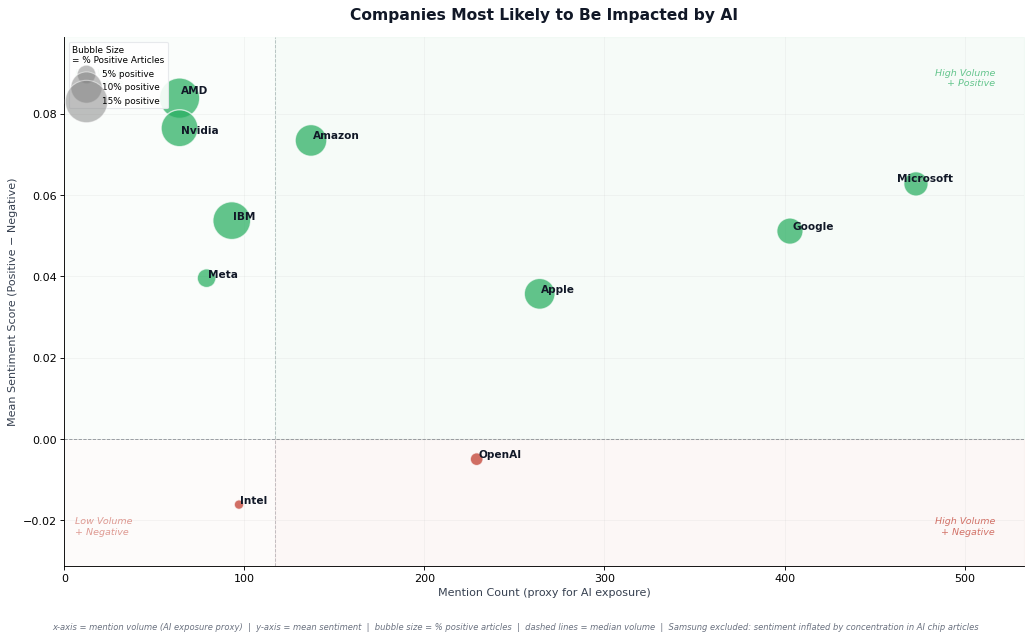

In [33]:
# ── CELL 18c: Company Impact Bubble Chart — Fixed ─────────────
import matplotlib.pyplot as plt
import numpy as np
from adjustText import adjust_text

# ── Remove Samsung + financial venues from this chart ──────────
EXCLUDE_BUBBLE = {"Samsung", "NYSE", "NASDAQ", "Nasdaq"}

plot_bubble = (
    org_summary_clean[~org_summary_clean["organization"].isin(EXCLUDE_BUBBLE)]
    .copy()
    .reset_index(drop=True)
)

fig, ax = plt.subplots(figsize=(13, 8))

size_scale = 25
sizes  = (plot_bubble["pct_positive"] ** 1.5) * size_scale
colors = [
    "#27ae60" if s >  0.01 else
    "#c0392b" if s < -0.001 else
    "#95a5a6"
    for s in plot_bubble["mean_sentiment"]
]

ax.scatter(
    plot_bubble["mention_count"],
    plot_bubble["mean_sentiment"],
    s=sizes, c=colors,
    alpha=0.72, edgecolors="white", linewidths=1.2, zorder=3
)

# ── Labels ─────────────────────────────────────────────────────
texts = []
for _, row in plot_bubble.iterrows():
    texts.append(ax.text(
        row["mention_count"], row["mean_sentiment"],
        row["organization"],
        fontsize=9.5, fontweight="600", color="#111827", zorder=5
    ))

adjust_text(
    texts, ax=ax,
    arrowprops=dict(arrowstyle="-", color="#aaa", lw=0.7),
    expand_points=(2.2, 2.2),
    expand_text=(1.8, 1.8)
)

# ── Reference lines ────────────────────────────────────────────
x_mid = plot_bubble["mention_count"].median()
ax.axhline(0,     color="#374151", linewidth=0.8, linestyle="--", alpha=0.5)
ax.axvline(x_mid, color="#374151", linewidth=0.8, linestyle="--", alpha=0.3)

# ── Quadrant shading ───────────────────────────────────────────
x_max = plot_bubble["mention_count"].max() + 60
y_max = plot_bubble["mean_sentiment"].max() + 0.015
y_min = plot_bubble["mean_sentiment"].min() - 0.015

ax.fill_between([x_mid, x_max], 0,     y_max, alpha=0.04, color="#27ae60")
ax.fill_between([x_mid, x_max], y_min, 0,     alpha=0.04, color="#c0392b")
ax.fill_between([0,     x_mid], 0,     y_max, alpha=0.02, color="#27ae60")
ax.fill_between([0,     x_mid], y_min, 0,     alpha=0.02, color="#c0392b")

# ── Quadrant labels ────────────────────────────────────────────
ax.text(x_max * 0.97, y_max * 0.88,
        "High Volume\n+ Positive",
        ha="right", fontsize=8.5, color="#27ae60", alpha=0.7, style="italic")
ax.text(x_max * 0.97, y_min * 0.75,
        "High Volume\n+ Negative",
        ha="right", fontsize=8.5, color="#c0392b", alpha=0.7, style="italic")
ax.text(x_mid * 0.05, y_max * 0.88,
        "Low Volume\n+ Positive",
        ha="left",  fontsize=8.5, color="#27ae60", alpha=0.5, style="italic")
ax.text(x_mid * 0.05, y_min * 0.75,
        "Low Volume\n+ Negative",
        ha="left",  fontsize=8.5, color="#c0392b", alpha=0.5, style="italic")

# ── Bubble size legend ─────────────────────────────────────────
for pct, label in [(5, "5% positive"), (10, "10% positive"), (15, "15% positive")]:
    ax.scatter([], [], s=(pct ** 1.5) * size_scale,
               color="gray", alpha=0.5, label=label,
               edgecolors="white", linewidths=1)
ax.legend(
    title="Bubble Size\n= % Positive Articles",
    title_fontsize=8, fontsize=8,
    loc="upper left", framealpha=0.9, edgecolor="#e5e7eb"
)

# ── Samsung footnote ───────────────────────────────────────────
fig.text(
    0.5, 0.01,
    "x-axis = mention volume (AI exposure proxy)  |  y-axis = mean sentiment  |  "
    "bubble size = % positive articles  |  dashed lines = median volume  |  "
    "Samsung excluded: sentiment inflated by concentration in AI chip articles",
    ha="center", fontsize=7.5, color="#6b7280", style="italic"
)

ax.set_xlim(0, x_max)
ax.set_ylim(y_min, y_max)
ax.set_xlabel("Mention Count (proxy for AI exposure)", fontsize=10, color="#374151")
ax.set_ylabel("Mean Sentiment Score (Positive − Negative)", fontsize=10, color="#374151")
ax.set_title(
    "Companies Most Likely to Be Impacted by AI",
    fontsize=14, fontweight="700", color="#111827", pad=16
)
ax.spines[["top", "right"]].set_visible(False)
ax.grid(alpha=0.12)

plt.tight_layout(rect=[0, 0.04, 1, 1])
plt.savefig(BASE + "company_impact_bubble.png", dpi=150, bbox_inches="tight")
plt.show()